In [1]:
import os
import sys
import warnings

warnings.filterwarnings("ignore")

print("Python Version:")
print(sys.version)

print("\nPython Executable:")
print(sys.executable)

print("\nCurrent Working Directory:")
print(os.getcwd())

Python Version:
3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]

Python Executable:
c:\Users\akgup\OneDrive\Documents\Desktop\LaptopPricePrediction\.venv\Scripts\python.exe

Current Working Directory:
c:\Users\akgup\OneDrive\Documents\Desktop\LaptopPricePrediction\notebooks


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import joblib

print("All required libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


All required libraries imported successfully.


In [3]:
dataset_path = "../data/laptop_data.csv"

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [5]:
df.tail()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1298,1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.64
1299,1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.72
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.12
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.92
1302,1302,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.32


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 1303
Number of columns: 12
Dataset shape: (1303, 12)


In [7]:
print("Dataset Columns:")

for index, column in enumerate(df.columns, start=1):
    print(index, column)

Dataset Columns:
1 Unnamed: 0
2 Company
3 TypeName
4 Inches
5 ScreenResolution
6 Cpu
7 Ram
8 Memory
9 Gpu
10 OpSys
11 Weight
12 Price


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   TypeName          1303 non-null   str    
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   str    
 5   Cpu               1303 non-null   str    
 6   Ram               1303 non-null   str    
 7   Memory            1303 non-null   str    
 8   Gpu               1303 non-null   str    
 9   OpSys             1303 non-null   str    
 10  Weight            1303 non-null   str    
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), str(9)
memory usage: 261.0 KB


In [9]:
df.describe()

,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [10]:
df.describe(include="object")

,Company,TypeName,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
count,1303,1303,1303,1303,1303,1303,1303,1303,1303
unique,19,6,40,118,9,39,110,9,179
top,Dell,Notebook,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg
freq,297,727,507,190,619,412,281,1072,121


In [11]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64


In [12]:
missing_values[missing_values > 0]

Series([], dtype: int64)

In [13]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [14]:
print(df.dtypes)

Unnamed: 0            int64
Company                 str
TypeName                str
Inches              float64
ScreenResolution        str
Cpu                     str
Ram                     str
Memory                  str
Gpu                     str
OpSys                   str
Weight                  str
Price               float64
dtype: object


In [15]:
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

Unnamed: 0: 1303 unique values
Company: 19 unique values
TypeName: 6 unique values
Inches: 18 unique values
ScreenResolution: 40 unique values
Cpu: 118 unique values
Ram: 9 unique values
Memory: 39 unique values
Gpu: 110 unique values
OpSys: 9 unique values
Weight: 179 unique values
Price: 791 unique values


In [16]:
print("Minimum Price:", df["Price"].min())
print("Maximum Price:", df["Price"].max())
print("Average Price:", df["Price"].mean())
print("Median Price:", df["Price"].median())

Minimum Price: 9270.72
Maximum Price: 324954.72
Average Price: 59870.042910207216
Median Price: 52054.56


In [17]:
print("=" * 60)
print("LAPTOP DATASET BASIC REPORT")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nTarget Column Statistics:")
print(df["Price"].describe())

print("=" * 60)

LAPTOP DATASET BASIC REPORT

Dataset Shape:
(1303, 12)

Column Names:
['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price']

Missing Values:
Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

Duplicate Rows:
0

Data Types:
Unnamed: 0            int64
Company                 str
TypeName                str
Inches              float64
ScreenResolution        str
Cpu                     str
Ram                     str
Memory                  str
Gpu                     str
OpSys                   str
Weight                  str
Price               float64
dtype: object

Target Column Statistics:
count      1303.000000
mean      59870.042910
std       37243.201786
min        9270.720000
25%     

In [18]:
laptop_df = df.copy()

print("Original dataset shape:", df.shape)
print("Copied dataset shape:", laptop_df.shape)

Original dataset shape: (1303, 12)
Copied dataset shape: (1303, 12)


In [19]:
laptop_df.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='str')

In [20]:
laptop_df.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='str')

In [21]:
if "Unnamed: 0" in laptop_df.columns:
    laptop_df.drop(columns=["Unnamed: 0"], inplace=True)

print(laptop_df.columns)

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='str')


In [22]:
if "Unnamed: 0" in laptop_df.columns:
    laptop_df.drop(columns=["Unnamed: 0"], inplace=True)

print(laptop_df.columns)

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='str')


In [23]:
print("Duplicates before removal:", laptop_df.duplicated().sum())

laptop_df.drop_duplicates(inplace=True)

print("Duplicates after removal:", laptop_df.duplicated().sum())
print("Dataset shape after duplicate removal:", laptop_df.shape)

Duplicates before removal: 29
Duplicates after removal: 0
Dataset shape after duplicate removal: (1274, 11)


In [24]:
missing_values = laptop_df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64


In [25]:
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [26]:
laptop_df["Ram"].head(10)

0     8GB
1     8GB
2     8GB
3    16GB
4     8GB
5     4GB
6    16GB
7     8GB
8    16GB
9     8GB
Name: Ram, dtype: str

In [27]:
laptop_df["Ram"] = (
    laptop_df["Ram"]
    .astype(str)
    .str.replace("GB", "", regex=False)
    .str.strip()
    .astype(int)
)

print(laptop_df["Ram"].head())
print("RAM datatype:", laptop_df["Ram"].dtype)

0     8
1     8
2     8
3    16
4     8
Name: Ram, dtype: int64
RAM datatype: int64


In [28]:
laptop_df.rename(columns={"Ram": "Ram_GB"}, inplace=True)

In [29]:
laptop_df[["Ram_GB"]].head()

,Ram_GB
0,8
1,8
2,8
3,16
4,8


In [30]:
laptop_df["Weight"].head(10)

0    1.37kg
1    1.34kg
2    1.86kg
3    1.83kg
4    1.37kg
5     2.1kg
6    2.04kg
7    1.34kg
8     1.3kg
9     1.6kg
Name: Weight, dtype: str

In [31]:
laptop_df["Weight"] = (
    laptop_df["Weight"]
    .astype(str)
    .str.replace("kg", "", regex=False)
    .str.strip()
)

laptop_df["Weight"] = pd.to_numeric(
    laptop_df["Weight"],
    errors="coerce"
)

In [32]:
laptop_df.rename(columns={"Weight": "Weight_kg"}, inplace=True)

In [33]:
print(laptop_df["Weight_kg"].head())
print("Weight datatype:", laptop_df["Weight_kg"].dtype)
print("Missing Weight values:", laptop_df["Weight_kg"].isnull().sum())

0    1.37
1    1.34
2    1.86
3    1.83
4    1.37
Name: Weight_kg, dtype: float64
Weight datatype: float64
Missing Weight values: 0


In [34]:
laptop_df["Weight_kg"] = laptop_df["Weight_kg"].fillna(
    laptop_df["Weight_kg"].median()
)

In [35]:
laptop_df["ScreenResolution"].head(15)

0     IPS Panel Retina Display 2560x1600
1                               1440x900
2                      Full HD 1920x1080
3     IPS Panel Retina Display 2880x1800
4     IPS Panel Retina Display 2560x1600
5                               1366x768
6     IPS Panel Retina Display 2880x1800
7                               1440x900
8                      Full HD 1920x1080
9            IPS Panel Full HD 1920x1080
10                              1366x768
11                     Full HD 1920x1080
12    IPS Panel Retina Display 2880x1800
13                     Full HD 1920x1080
14    IPS Panel Retina Display 2304x1440
Name: ScreenResolution, dtype: str

In [36]:
laptop_df["Touchscreen"] = laptop_df["ScreenResolution"].apply(
    lambda value: 1 if "Touchscreen" in str(value) else 0
)

In [37]:
laptop_df[["ScreenResolution", "Touchscreen"]].head(10)

,ScreenResolution,Touchscreen
0,IPS Panel Retina Display 2560x1600,0
1,1440x900,0
2,Full HD 1920x1080,0
3,IPS Panel Retina Display 2880x1800,0
4,IPS Panel Retina Display 2560x1600,0
5,1366x768,0
6,IPS Panel Retina Display 2880x1800,0
7,1440x900,0
8,Full HD 1920x1080,0
9,IPS Panel Full HD 1920x1080,0


In [38]:
laptop_df["Touchscreen"].value_counts()

Touchscreen
0    1086
1     188
Name: count, dtype: int64

In [39]:
laptop_df["IPS"] = laptop_df["ScreenResolution"].apply(
    lambda value: 1 if "IPS" in str(value) else 0
)

In [40]:
laptop_df[["ScreenResolution", "IPS"]].head(10)

,ScreenResolution,IPS
0,IPS Panel Retina Display 2560x1600,1
1,1440x900,0
2,Full HD 1920x1080,0
3,IPS Panel Retina Display 2880x1800,1
4,IPS Panel Retina Display 2560x1600,1
5,1366x768,0
6,IPS Panel Retina Display 2880x1800,1
7,1440x900,0
8,Full HD 1920x1080,0
9,IPS Panel Full HD 1920x1080,1


In [41]:
resolution = laptop_df["ScreenResolution"].str.extract(
    r"(\d+)x(\d+)"
)

laptop_df["X_resolution"] = pd.to_numeric(
    resolution[0],
    errors="coerce"
)

laptop_df["Y_resolution"] = pd.to_numeric(
    resolution[1],
    errors="coerce"
)

In [42]:
laptop_df[
    ["ScreenResolution", "X_resolution", "Y_resolution"]
].head(10)

,ScreenResolution,X_resolution,Y_resolution
0,IPS Panel Retina Display 2560x1600,2560,1600
1,1440x900,1440,900
2,Full HD 1920x1080,1920,1080
3,IPS Panel Retina Display 2880x1800,2880,1800
4,IPS Panel Retina Display 2560x1600,2560,1600
5,1366x768,1366,768
6,IPS Panel Retina Display 2880x1800,2880,1800
7,1440x900,1440,900
8,Full HD 1920x1080,1920,1080
9,IPS Panel Full HD 1920x1080,1920,1080


In [43]:
print(
    laptop_df[
        ["X_resolution", "Y_resolution"]
    ].isnull().sum()
)

X_resolution    0
Y_resolution    0
dtype: int64


In [44]:
laptop_df["PPI"] = (
    (
        laptop_df["X_resolution"] ** 2
        + laptop_df["Y_resolution"] ** 2
    ) ** 0.5
) / laptop_df["Inches"]

In [45]:
laptop_df[
    ["Inches", "X_resolution", "Y_resolution", "PPI"]
].head()

,Inches,X_resolution,Y_resolution,PPI
0,13.3,2560,1600,226.983005
1,13.3,1440,900,127.677940
2,15.6,1920,1080,141.211998
3,15.4,2880,1800,220.534624
4,13.3,2560,1600,226.983005


In [46]:
laptop_df["Cpu"].head(15)

0           Intel Core i5 2.3GHz
1           Intel Core i5 1.8GHz
2     Intel Core i5 7200U 2.5GHz
3           Intel Core i7 2.7GHz
4           Intel Core i5 3.1GHz
5        AMD A9-Series 9420 3GHz
6           Intel Core i7 2.2GHz
7           Intel Core i5 1.8GHz
8     Intel Core i7 8550U 1.8GHz
9     Intel Core i5 8250U 1.6GHz
10    Intel Core i5 7200U 2.5GHz
11      Intel Core i3 6006U 2GHz
12          Intel Core i7 2.8GHz
13      Intel Core i3 6006U 2GHz
14        Intel Core M m3 1.2GHz
Name: Cpu, dtype: str

In [47]:
laptop_df["CPU_Name"] = laptop_df["Cpu"].apply(
    lambda value: " ".join(str(value).split()[0:3])
)

In [48]:
laptop_df[["Cpu", "CPU_Name"]].head(15)

,Cpu,CPU_Name
0,Intel Core i5 2.3GHz,Intel Core i5
1,Intel Core i5 1.8GHz,Intel Core i5
2,Intel Core i5 7200U 2.5GHz,Intel Core i5
3,Intel Core i7 2.7GHz,Intel Core i7
4,Intel Core i5 3.1GHz,Intel Core i5
5,AMD A9-Series 9420 3GHz,AMD A9-Series 9420
6,Intel Core i7 2.2GHz,Intel Core i7
7,Intel Core i5 1.8GHz,Intel Core i5
8,Intel Core i7 8550U 1.8GHz,Intel Core i7
9,Intel Core i5 8250U 1.6GHz,Intel Core i5


In [49]:
def categorize_cpu(cpu_name):
    cpu_name = str(cpu_name)

    if "Intel Core i7" in cpu_name:
        return "Intel Core i7"

    elif "Intel Core i5" in cpu_name:
        return "Intel Core i5"

    elif "Intel Core i3" in cpu_name:
        return "Intel Core i3"

    elif cpu_name.startswith("Intel"):
        return "Other Intel Processor"

    elif cpu_name.startswith("AMD"):
        return "AMD Processor"

    else:
        return "Other Processor"

In [50]:
laptop_df["CPU_Brand"] = laptop_df["CPU_Name"].apply(
    categorize_cpu
)

In [51]:
laptop_df[
    ["Cpu", "CPU_Name", "CPU_Brand"]
].head(15)

,Cpu,CPU_Name,CPU_Brand
0,Intel Core i5 2.3GHz,Intel Core i5,Intel Core i5
1,Intel Core i5 1.8GHz,Intel Core i5,Intel Core i5
2,Intel Core i5 7200U 2.5GHz,Intel Core i5,Intel Core i5
3,Intel Core i7 2.7GHz,Intel Core i7,Intel Core i7
4,Intel Core i5 3.1GHz,Intel Core i5,Intel Core i5
5,AMD A9-Series 9420 3GHz,AMD A9-Series 9420,AMD Processor
6,Intel Core i7 2.2GHz,Intel Core i7,Intel Core i7
7,Intel Core i5 1.8GHz,Intel Core i5,Intel Core i5
8,Intel Core i7 8550U 1.8GHz,Intel Core i7,Intel Core i7
9,Intel Core i5 8250U 1.6GHz,Intel Core i5,Intel Core i5


In [52]:
laptop_df["CPU_Brand"].value_counts()

CPU_Brand
Intel Core i7            515
Intel Core i5            423
Other Intel Processor    141
Intel Core i3            134
AMD Processor             60
Other Processor            1
Name: count, dtype: int64

In [53]:
laptop_df["Memory"].value_counts().head(20)

Memory
256GB SSD               412
1TB HDD                 215
500GB HDD               123
512GB SSD               114
128GB SSD +  1TB HDD     94
128GB SSD                74
256GB SSD +  1TB HDD     73
32GB Flash Storage       36
2TB HDD                  16
512GB SSD +  1TB HDD     14
1TB SSD                  14
64GB Flash Storage       13
256GB SSD +  2TB HDD     10
256GB Flash Storage       8
1.0TB Hybrid              7
16GB Flash Storage        7
32GB SSD                  6
180GB SSD                 5
128GB Flash Storage       4
16GB SSD                  3
Name: count, dtype: int64

In [54]:
import re

def convert_storage_to_gb(value):
    value = str(value).strip()

    match = re.search(r"([\d.]+)\s*(TB|GB)", value, re.IGNORECASE)

    if not match:
        return 0

    number = float(match.group(1))
    unit = match.group(2).upper()

    if unit == "TB":
        return int(number * 1024)

    return int(number)

In [55]:
def extract_storage(memory_value, storage_type):
    memory_value = str(memory_value)

    total_storage = 0

    parts = memory_value.split("+")

    for part in parts:
        part = part.strip()

        if storage_type.lower() in part.lower():
            total_storage += convert_storage_to_gb(part)

    return total_storage

In [56]:
laptop_df["SSD_GB"] = laptop_df["Memory"].apply(
    lambda value: extract_storage(value, "SSD")
)

laptop_df["HDD_GB"] = laptop_df["Memory"].apply(
    lambda value: extract_storage(value, "HDD")
)

laptop_df["Flash_GB"] = laptop_df["Memory"].apply(
    lambda value: extract_storage(value, "Flash Storage")
)

laptop_df["Hybrid_GB"] = laptop_df["Memory"].apply(
    lambda value: extract_storage(value, "Hybrid")
)

In [57]:
laptop_df[
    [
        "Memory",
        "SSD_GB",
        "HDD_GB",
        "Flash_GB",
        "Hybrid_GB"
    ]
].head(20)

,Memory,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB
0,128GB SSD,128,0,0,0
1,128GB Flash Storage,0,0,128,0
2,256GB SSD,256,0,0,0
3,512GB SSD,512,0,0,0
4,256GB SSD,256,0,0,0
5,500GB HDD,0,500,0,0
6,256GB Flash Storage,0,0,256,0
7,256GB Flash Storage,0,0,256,0
8,512GB SSD,512,0,0,0
9,256GB SSD,256,0,0,0


In [58]:
laptop_df["Gpu"].head(15)

0     Intel Iris Plus Graphics 640
1           Intel HD Graphics 6000
2            Intel HD Graphics 620
3               AMD Radeon Pro 455
4     Intel Iris Plus Graphics 650
5                    AMD Radeon R5
6          Intel Iris Pro Graphics
7           Intel HD Graphics 6000
8             Nvidia GeForce MX150
9           Intel UHD Graphics 620
10           Intel HD Graphics 620
11           Intel HD Graphics 520
12              AMD Radeon Pro 555
13              AMD Radeon R5 M430
14           Intel HD Graphics 615
Name: Gpu, dtype: str

In [59]:
laptop_df["GPU_Brand"] = laptop_df["Gpu"].apply(
    lambda value: str(value).split()[0]
)

In [60]:
laptop_df[["Gpu", "GPU_Brand"]].head(10)

,Gpu,GPU_Brand
0,Intel Iris Plus Graphics 640,Intel
1,Intel HD Graphics 6000,Intel
2,Intel HD Graphics 620,Intel
3,AMD Radeon Pro 455,AMD
4,Intel Iris Plus Graphics 650,Intel
5,AMD Radeon R5,AMD
6,Intel Iris Pro Graphics,Intel
7,Intel HD Graphics 6000,Intel
8,Nvidia GeForce MX150,Nvidia
9,Intel UHD Graphics 620,Intel


In [61]:
laptop_df["GPU_Brand"].value_counts()

GPU_Brand
Intel     703
Nvidia    396
AMD       174
ARM         1
Name: count, dtype: int64

In [62]:
laptop_df["OpSys"].value_counts()

OpSys
Windows 10      1047
No OS             66
Linux             58
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [63]:
def categorize_os(os_name):
    os_name = str(os_name)

    if os_name in [
        "Windows 10",
        "Windows 7",
        "Windows 10 S"
    ]:
        return "Windows"

    elif os_name in [
        "macOS",
        "Mac OS X"
    ]:
        return "Mac"

    elif os_name == "Linux":
        return "Linux"

    else:
        return "Other"

In [64]:
laptop_df["OS"] = laptop_df["OpSys"].apply(
    categorize_os
)

In [65]:
laptop_df[["OpSys", "OS"]].head(15)

,OpSys,OS
0,macOS,Mac
1,macOS,Mac
2,No OS,Other
3,macOS,Mac
4,macOS,Mac
5,Windows 10,Windows
6,Mac OS X,Mac
7,macOS,Mac
8,Windows 10,Windows
9,Windows 10,Windows


In [66]:
laptop_df["OS"].value_counts()

OS
Windows    1100
Other        95
Linux        58
Mac          21
Name: count, dtype: int64

In [67]:
print(laptop_df["Price"].dtype)
print(laptop_df["Price"].head())

float64
0     71378.6832
1     47895.5232
2     30636.0000
3    135195.3360
4     96095.8080
Name: Price, dtype: float64


In [68]:
laptop_df["Price"] = pd.to_numeric(
    laptop_df["Price"],
    errors="coerce"
)

In [69]:
print("Missing price values:", laptop_df["Price"].isnull().sum())

Missing price values: 0


In [70]:
laptop_df.dropna(subset=["Price"], inplace=True)

In [71]:
columns_to_drop = [
    "ScreenResolution",
    "Cpu",
    "CPU_Name",
    "Memory",
    "Gpu",
    "OpSys",
    "X_resolution",
    "Y_resolution"
]

laptop_df.drop(
    columns=columns_to_drop,
    inplace=True,
    errors="ignore"
)

In [72]:
laptop_df.head()

,Company,TypeName,Inches,Ram_GB,Weight_kg,Price,Touchscreen,IPS,PPI,CPU_Brand,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB,GPU_Brand,OS
0,Apple,Ultrabook,13.3,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,128,0,0,0,Intel,Mac
1,Apple,Ultrabook,13.3,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,128,0,Intel,Mac
2,HP,Notebook,15.6,8,1.86,30636.0000,0,0,141.211998,Intel Core i5,256,0,0,0,Intel,Other
3,Apple,Ultrabook,15.4,16,1.83,135195.3360,0,1,220.534624,Intel Core i7,512,0,0,0,AMD,Mac
4,Apple,Ultrabook,13.3,8,1.37,96095.8080,0,1,226.983005,Intel Core i5,256,0,0,0,Intel,Mac


In [73]:
laptop_df.columns.tolist()

['Company',
 'TypeName',
 'Inches',
 'Ram_GB',
 'Weight_kg',
 'Price',
 'Touchscreen',
 'IPS',
 'PPI',
 'CPU_Brand',
 'SSD_GB',
 'HDD_GB',
 'Flash_GB',
 'Hybrid_GB',
 'GPU_Brand',
 'OS']

In [74]:
print("=" * 60)
print("FINAL CLEANING REPORT")
print("=" * 60)

print("\nDataset Shape:")
print(laptop_df.shape)

print("\nColumns:")
print(laptop_df.columns.tolist())

print("\nMissing Values:")
print(laptop_df.isnull().sum())

print("\nDuplicate Rows:")
print(laptop_df.duplicated().sum())

print("\nData Types:")
print(laptop_df.dtypes)

print("=" * 60)

FINAL CLEANING REPORT

Dataset Shape:
(1274, 16)

Columns:
['Company', 'TypeName', 'Inches', 'Ram_GB', 'Weight_kg', 'Price', 'Touchscreen', 'IPS', 'PPI', 'CPU_Brand', 'SSD_GB', 'HDD_GB', 'Flash_GB', 'Hybrid_GB', 'GPU_Brand', 'OS']

Missing Values:
Company        0
TypeName       0
Inches         0
Ram_GB         0
Weight_kg      0
Price          0
Touchscreen    0
IPS            0
PPI            0
CPU_Brand      0
SSD_GB         0
HDD_GB         0
Flash_GB       0
Hybrid_GB      0
GPU_Brand      0
OS             0
dtype: int64

Duplicate Rows:
1

Data Types:
Company            str
TypeName           str
Inches         float64
Ram_GB           int64
Weight_kg      float64
Price          float64
Touchscreen      int64
IPS              int64
PPI            float64
CPU_Brand          str
SSD_GB           int64
HDD_GB           int64
Flash_GB         int64
Hybrid_GB        int64
GPU_Brand          str
OS                 str
dtype: object


In [75]:
cleaned_file_path = "../data/cleaned_laptop_data.csv"

laptop_df.to_csv(
    cleaned_file_path,
    index=False
)

print("Cleaned dataset saved successfully.")
print("Saved at:", cleaned_file_path)

Cleaned dataset saved successfully.
Saved at: ../data/cleaned_laptop_data.csv


In [76]:
test_df = pd.read_csv("../data/cleaned_laptop_data.csv")

print(test_df.head())
print(test_df.shape)

  Company   TypeName  Inches  Ram_GB  Weight_kg        Price  Touchscreen  \
0   Apple  Ultrabook    13.3       8       1.37   71378.6832            0   
1   Apple  Ultrabook    13.3       8       1.34   47895.5232            0   
2      HP   Notebook    15.6       8       1.86   30636.0000            0   
3   Apple  Ultrabook    15.4      16       1.83  135195.3360            0   
4   Apple  Ultrabook    13.3       8       1.37   96095.8080            0   

   IPS         PPI      CPU_Brand  SSD_GB  HDD_GB  Flash_GB  Hybrid_GB  \
0    1  226.983005  Intel Core i5     128       0         0          0   
1    0  127.677940  Intel Core i5       0       0       128          0   
2    0  141.211998  Intel Core i5     256       0         0          0   
3    1  220.534624  Intel Core i7     512       0         0          0   
4    1  226.983005  Intel Core i5     256       0         0          0   

  GPU_Brand     OS  
0     Intel    Mac  
1     Intel    Mac  
2     Intel  Other  
3       

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

In [78]:
print("Rows :", laptop_df.shape[0])
print("Columns :", laptop_df.shape[1])

laptop_df.head()

Rows : 1274
Columns : 16


,Company,TypeName,Inches,Ram_GB,Weight_kg,Price,Touchscreen,IPS,PPI,CPU_Brand,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB,GPU_Brand,OS
0,Apple,Ultrabook,13.3,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,128,0,0,0,Intel,Mac
1,Apple,Ultrabook,13.3,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,128,0,Intel,Mac
2,HP,Notebook,15.6,8,1.86,30636.0000,0,0,141.211998,Intel Core i5,256,0,0,0,Intel,Other
3,Apple,Ultrabook,15.4,16,1.83,135195.3360,0,1,220.534624,Intel Core i7,512,0,0,0,AMD,Mac
4,Apple,Ultrabook,13.3,8,1.37,96095.8080,0,1,226.983005,Intel Core i5,256,0,0,0,Intel,Mac


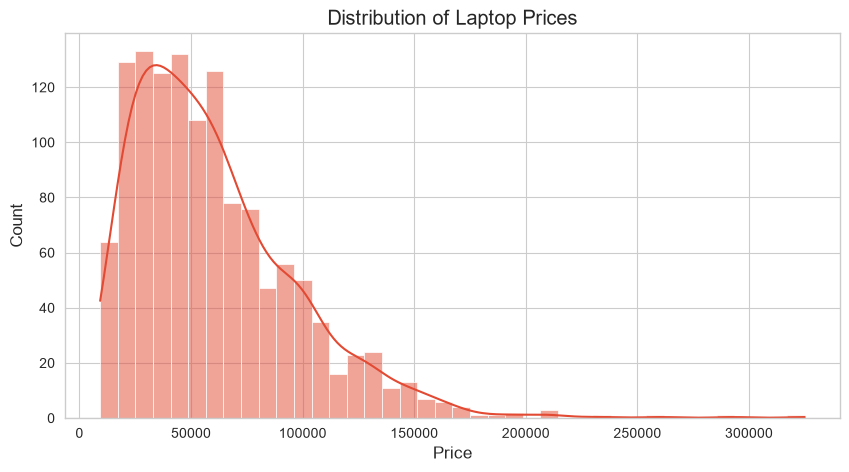

In [79]:
plt.figure(figsize=(10,5))

sns.histplot(
    laptop_df["Price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

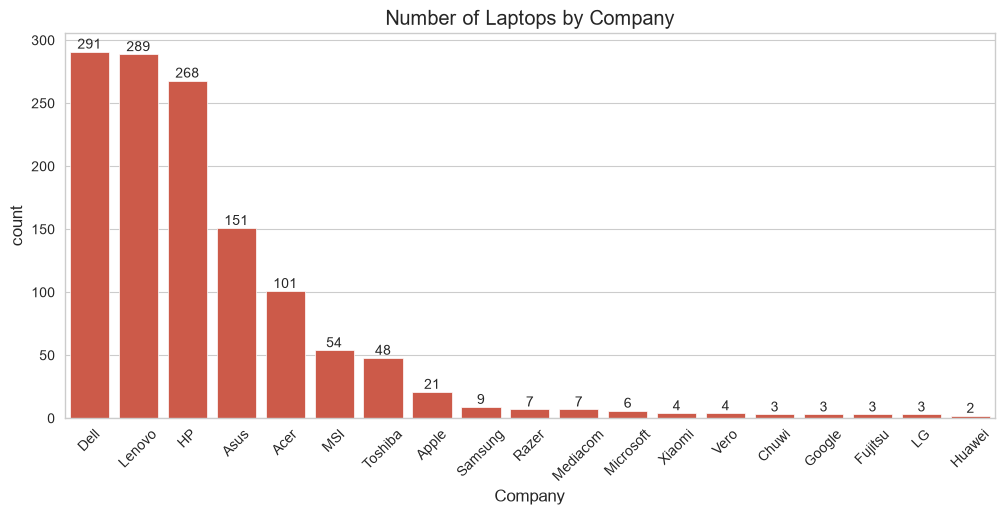

In [80]:
plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=laptop_df,
    x="Company",
    order=laptop_df["Company"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Number of Laptops by Company")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

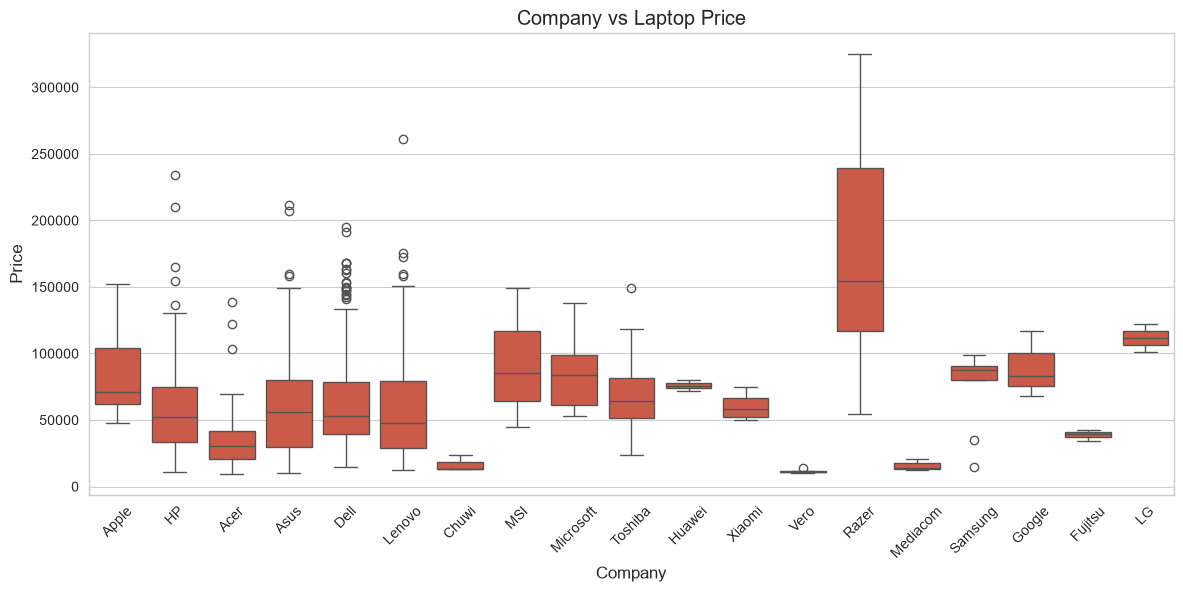

In [81]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=laptop_df,
    x="Company",
    y="Price"
)

plt.xticks(rotation=45)

plt.title("Company vs Laptop Price")

plt.show()

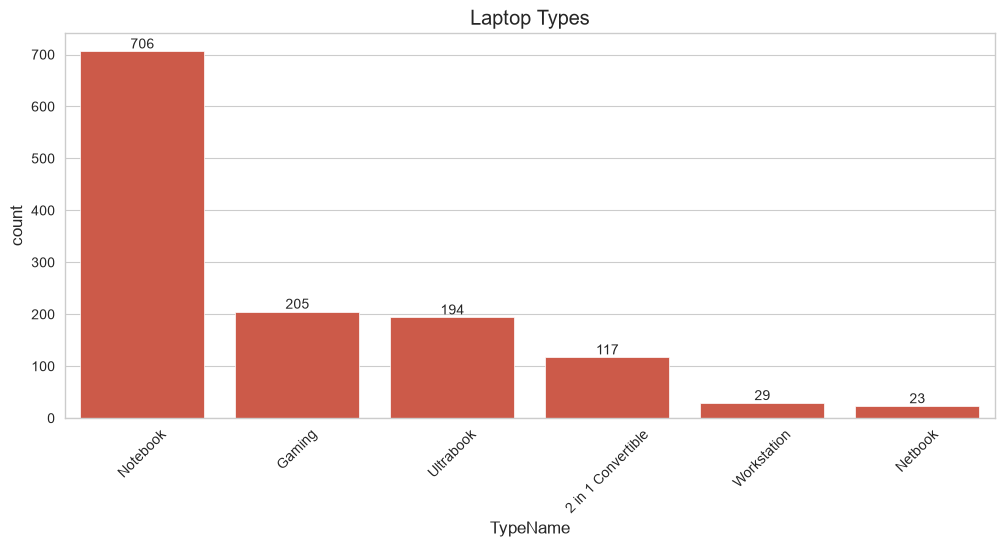

In [82]:
plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=laptop_df,
    x="TypeName",
    order=laptop_df["TypeName"].value_counts().index
)

plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Laptop Types")

plt.show()

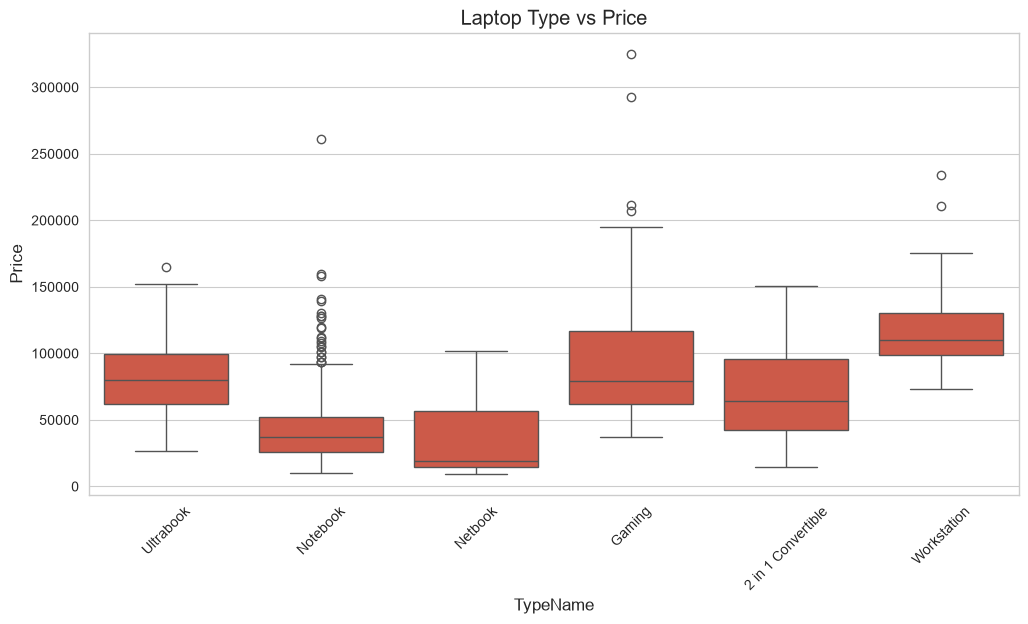

In [83]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=laptop_df,
    x="TypeName",
    y="Price"
)

plt.xticks(rotation=45)

plt.title("Laptop Type vs Price")

plt.show()

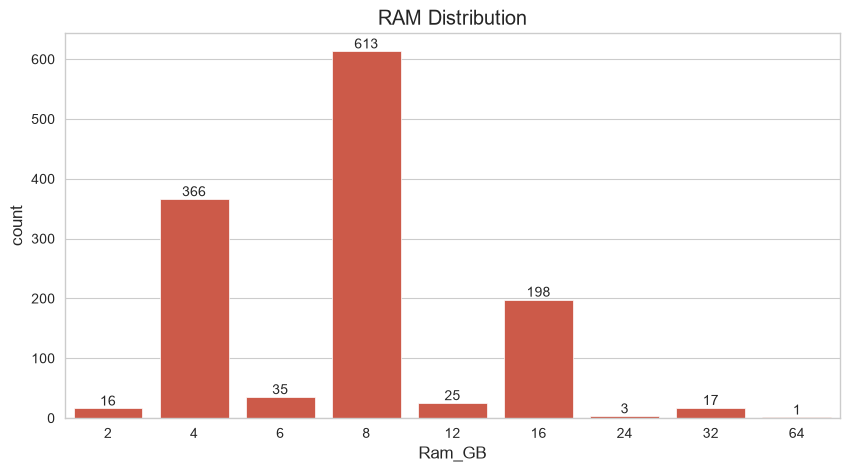

In [84]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=laptop_df,
    x="Ram_GB"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("RAM Distribution")

plt.show()

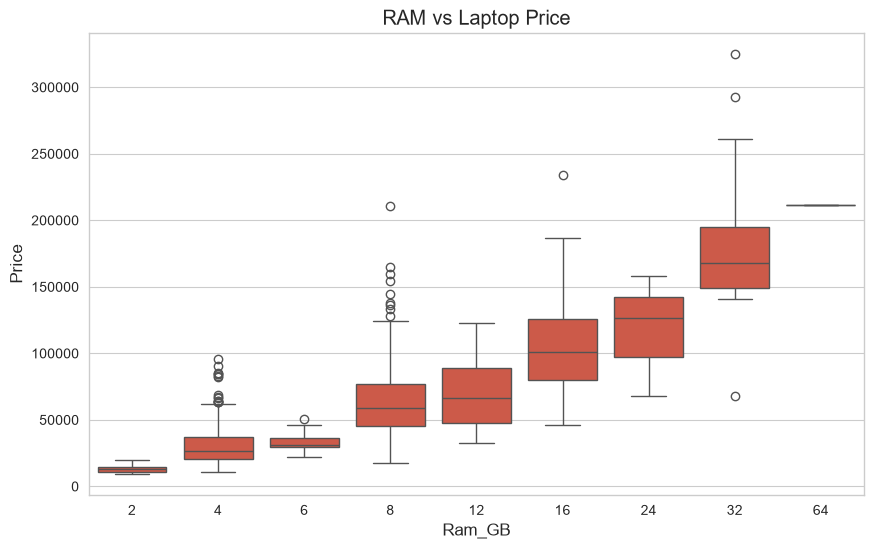

In [85]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=laptop_df,
    x="Ram_GB",
    y="Price"
)

plt.title("RAM vs Laptop Price")

plt.show()

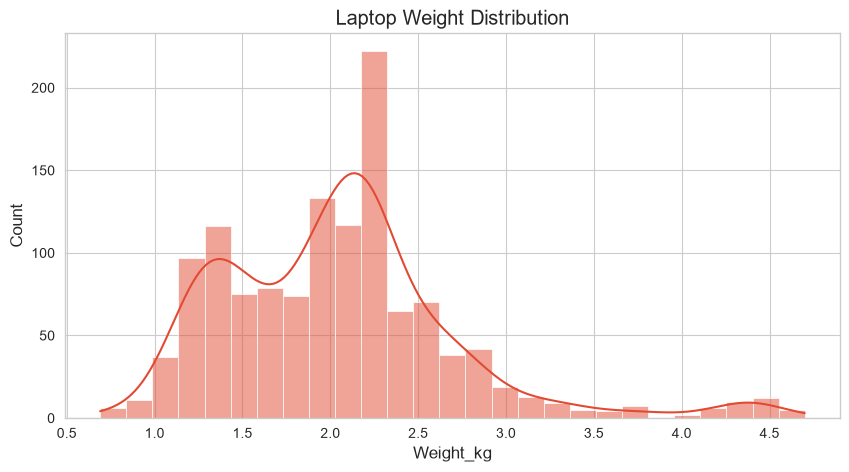

In [86]:
plt.figure(figsize=(10,5))

sns.histplot(
    laptop_df["Weight_kg"],
    kde=True
)

plt.title("Laptop Weight Distribution")

plt.show()

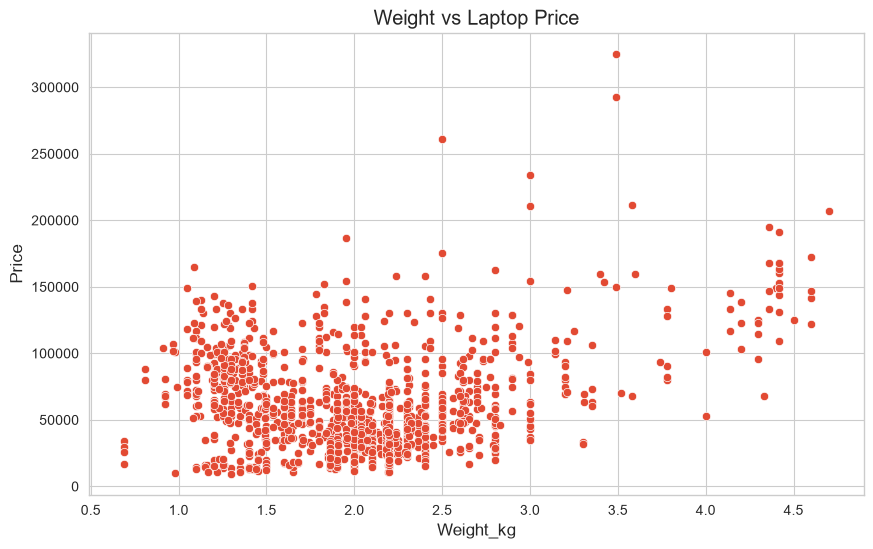

In [87]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=laptop_df,
    x="Weight_kg",
    y="Price"
)

plt.title("Weight vs Laptop Price")

plt.show()

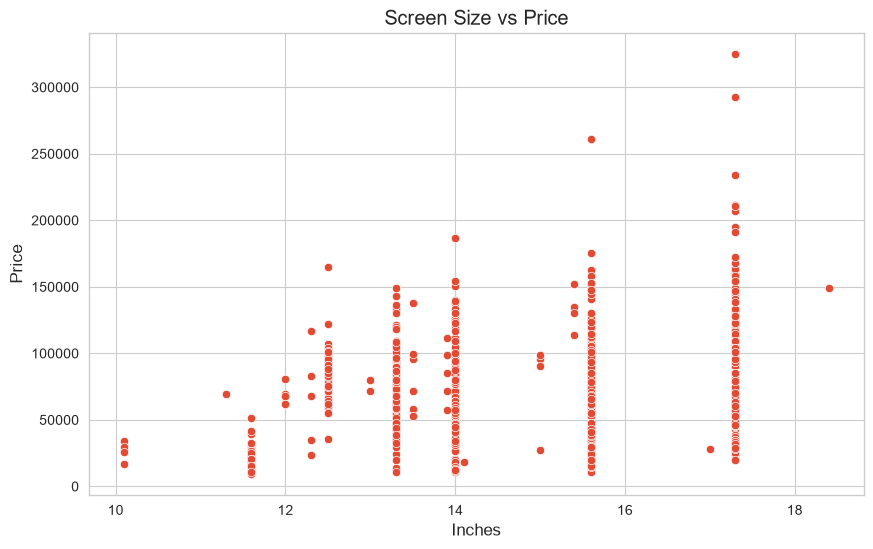

In [88]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=laptop_df,
    x="Inches",
    y="Price"
)

plt.title("Screen Size vs Price")

plt.show()

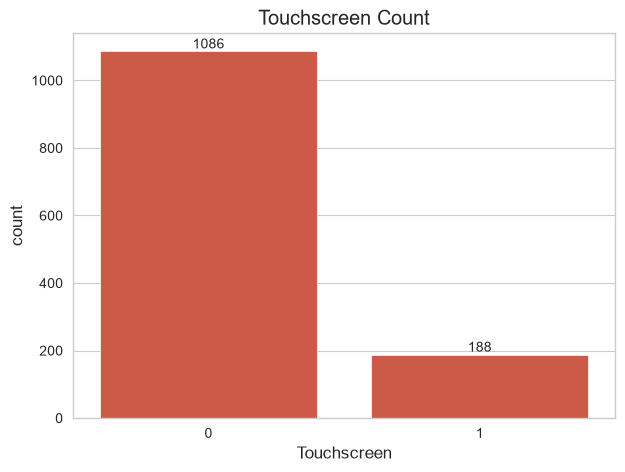

In [89]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=laptop_df,
    x="Touchscreen"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Touchscreen Count")

plt.show()

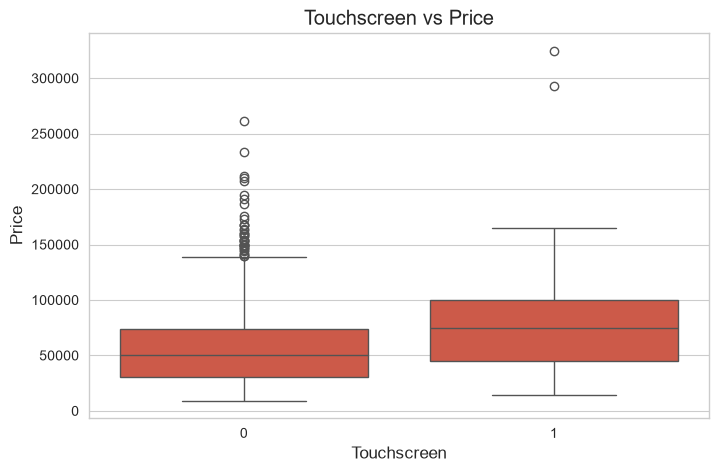

In [90]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=laptop_df,
    x="Touchscreen",
    y="Price"
)

plt.title("Touchscreen vs Price")

plt.show()

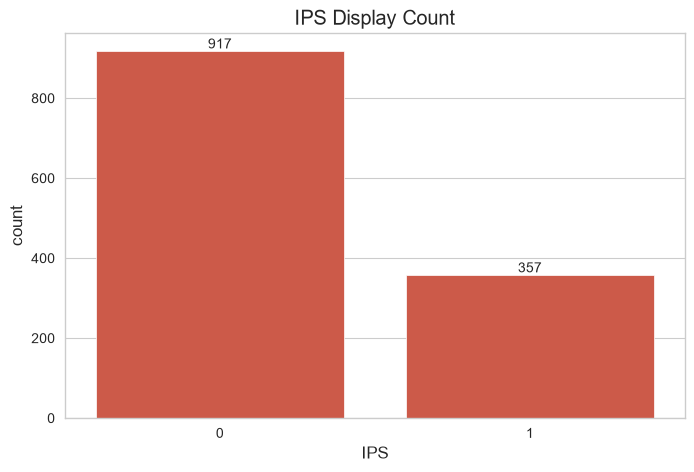

In [91]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=laptop_df,
    x="IPS"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("IPS Display Count")

plt.show()

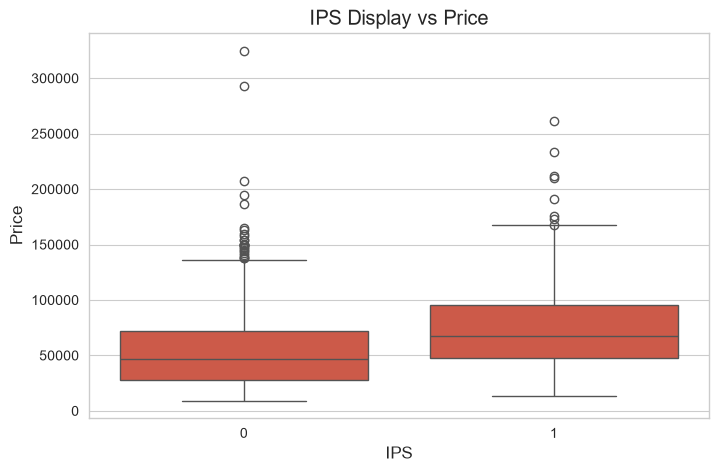

In [92]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=laptop_df,
    x="IPS",
    y="Price"
)

plt.title("IPS Display vs Price")

plt.show()

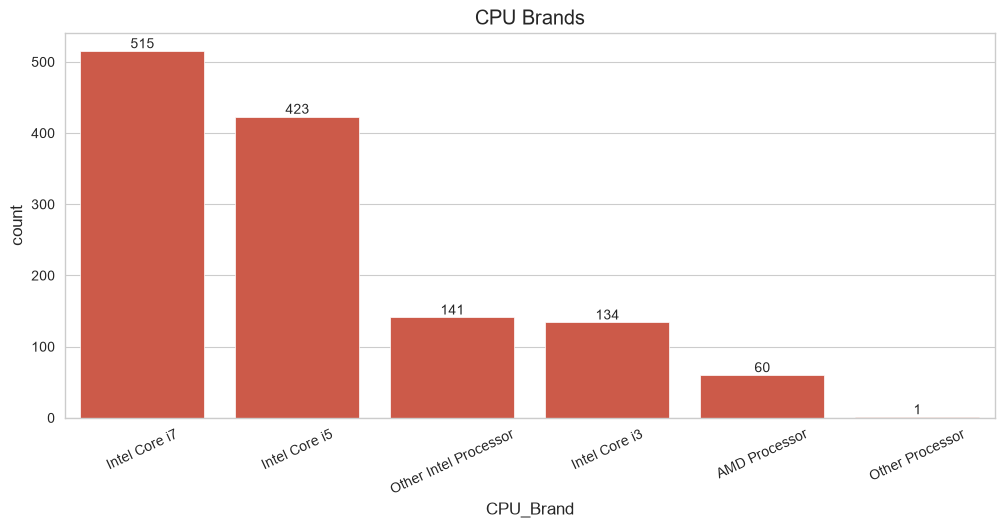

In [93]:
plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=laptop_df,
    x="CPU_Brand",
    order=laptop_df["CPU_Brand"].value_counts().index
)

plt.xticks(rotation=25)

for container in ax.containers:
    ax.bar_label(container)

plt.title("CPU Brands")

plt.show()

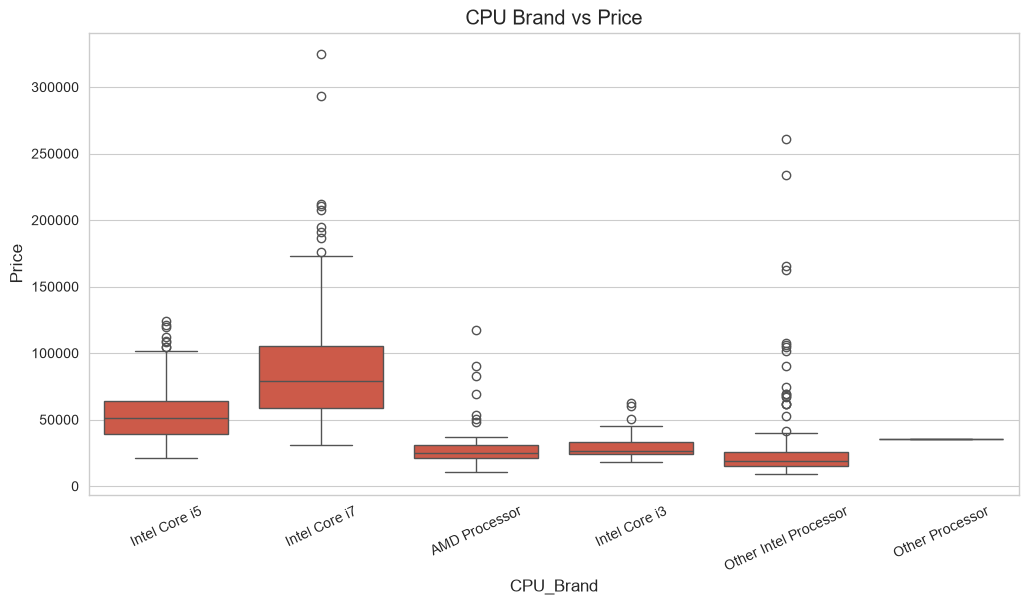

In [94]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=laptop_df,
    x="CPU_Brand",
    y="Price"
)

plt.xticks(rotation=25)

plt.title("CPU Brand vs Price")

plt.show()

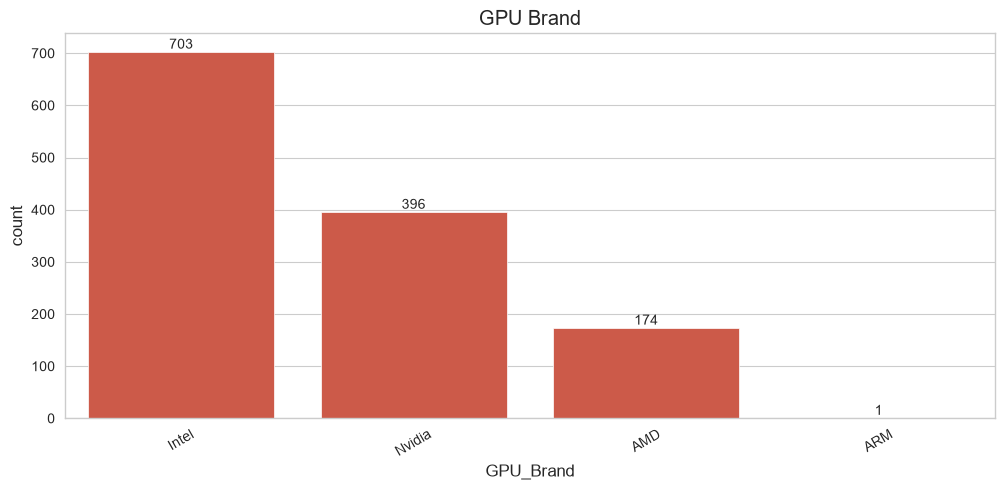

In [95]:
plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=laptop_df,
    x="GPU_Brand",
    order=laptop_df["GPU_Brand"].value_counts().index
)

plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container)

plt.title("GPU Brand")

plt.show()

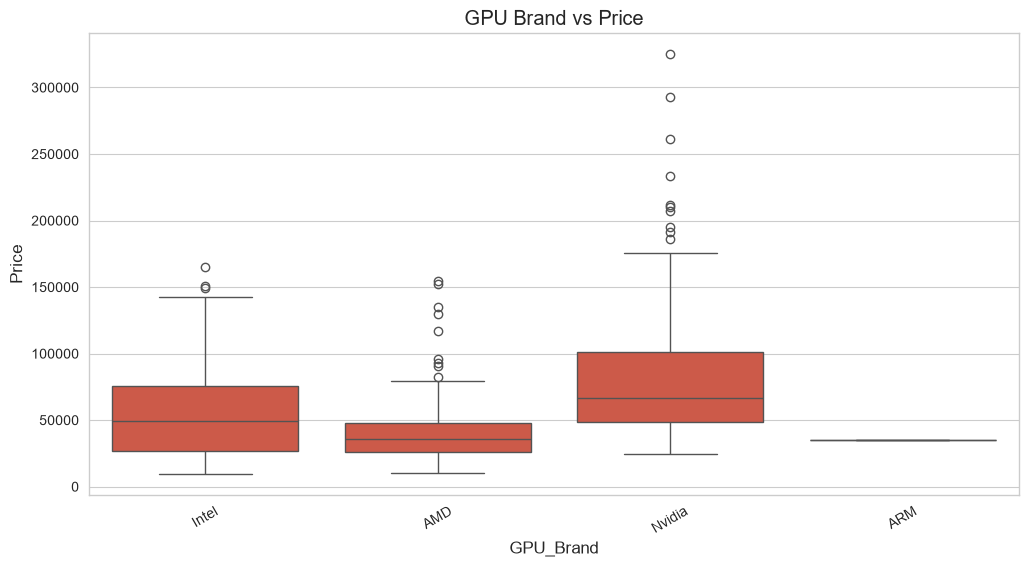

In [96]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=laptop_df,
    x="GPU_Brand",
    y="Price"
)

plt.xticks(rotation=30)

plt.title("GPU Brand vs Price")

plt.show()

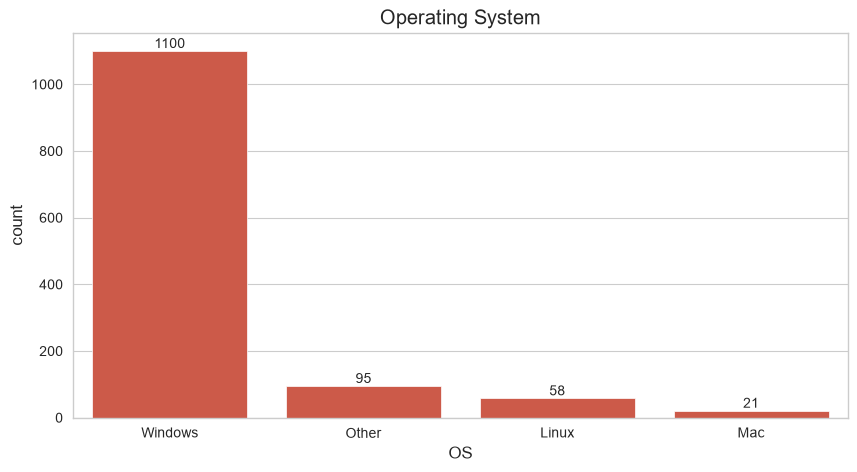

In [97]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=laptop_df,
    x="OS",
    order=laptop_df["OS"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Operating System")

plt.show()

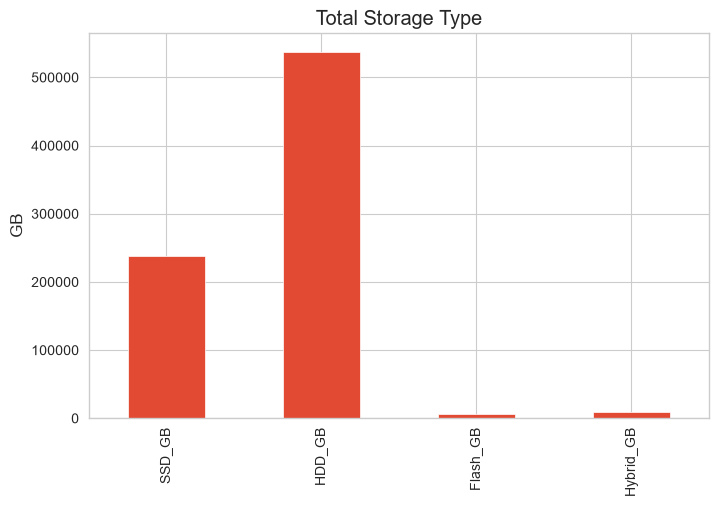

In [98]:
storage_cols = [
    "SSD_GB",
    "HDD_GB",
    "Flash_GB",
    "Hybrid_GB"
]

laptop_df[storage_cols].sum().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Storage Type")

plt.ylabel("GB")

plt.show()

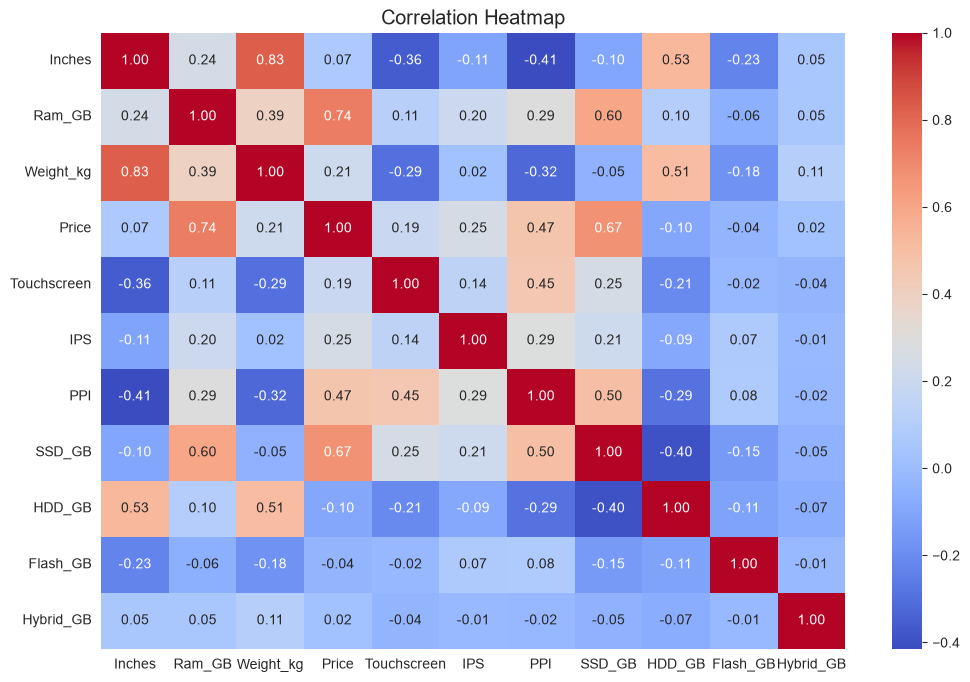

In [99]:
numeric_df = laptop_df.select_dtypes(include=["number"])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

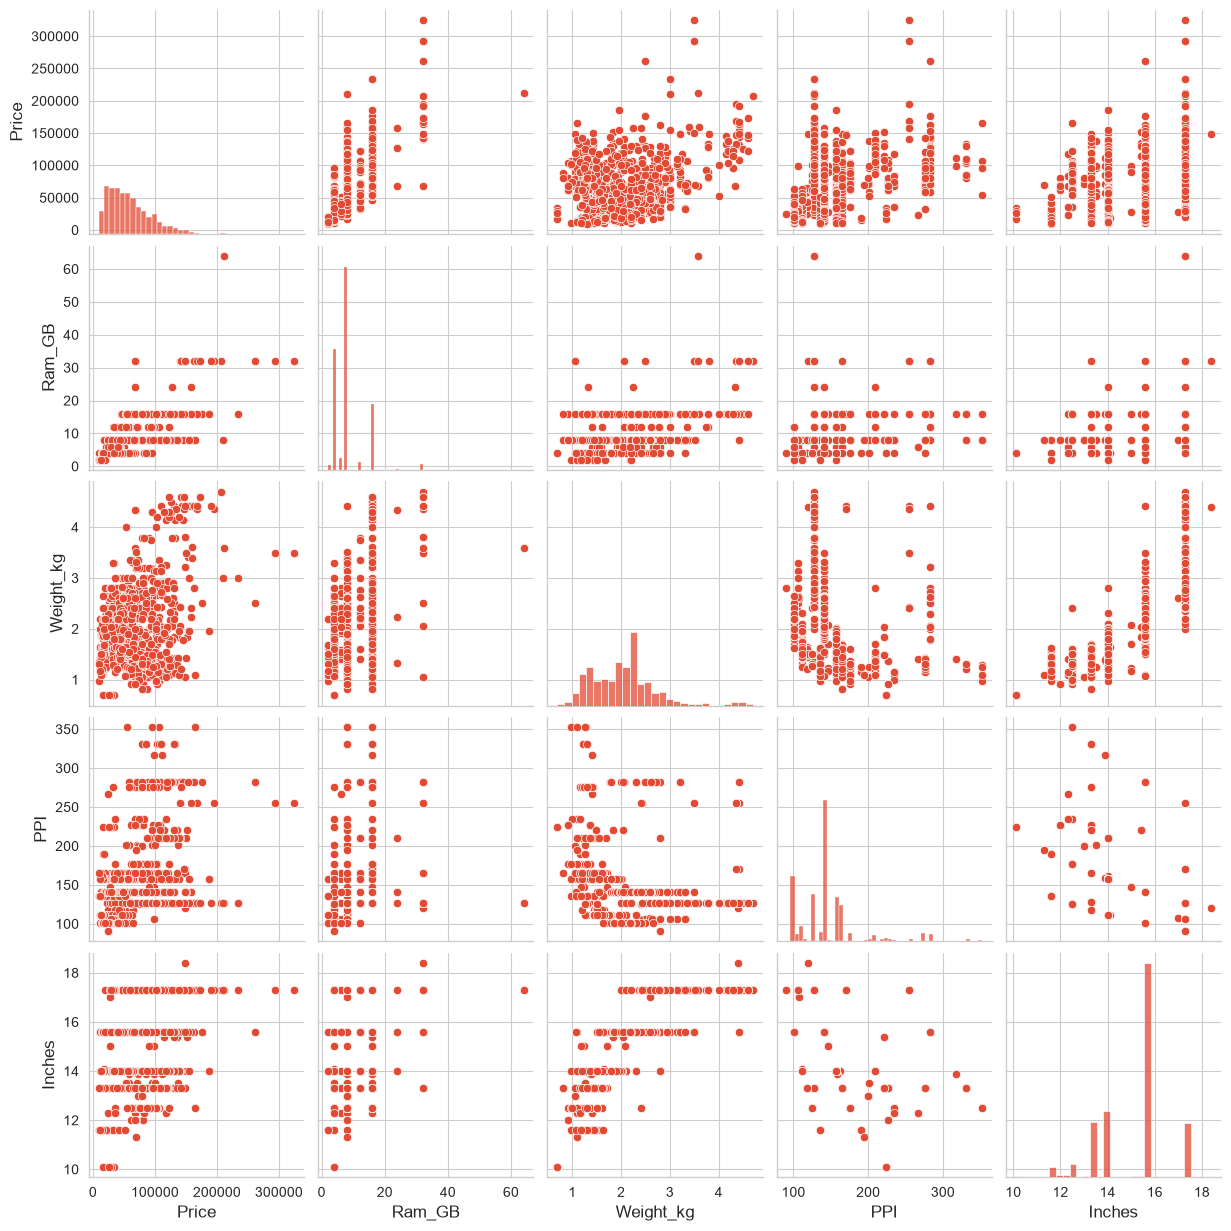

In [100]:
sns.pairplot(
    laptop_df[
        [
            "Price",
            "Ram_GB",
            "Weight_kg",
            "PPI",
            "Inches"
        ]
    ]
)

plt.show()

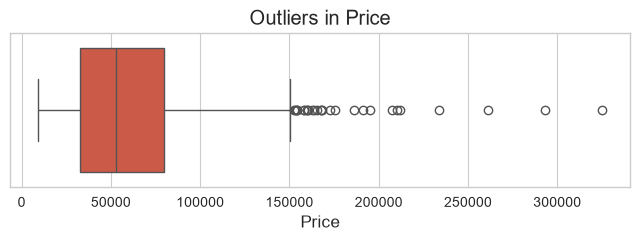

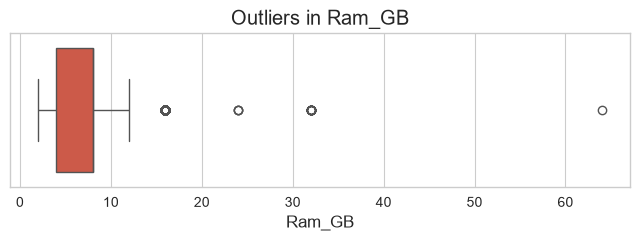

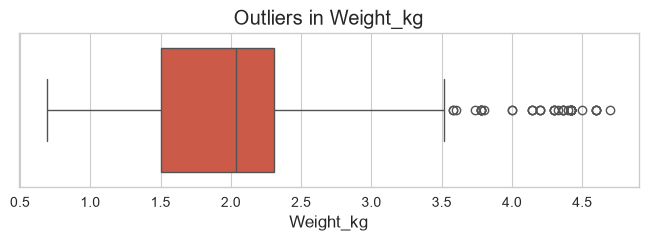

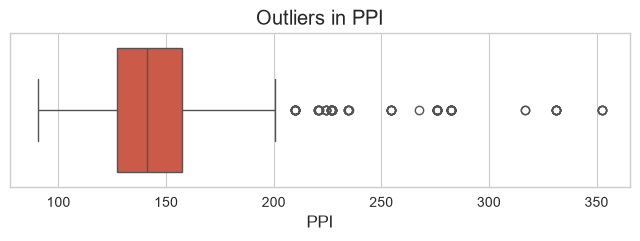

In [101]:
numeric_cols = [
    "Price",
    "Ram_GB",
    "Weight_kg",
    "PPI"
]

for col in numeric_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=laptop_df[col]
    )

    plt.title(f"Outliers in {col}")

    plt.show()

In [102]:
print("="*60)
print("EDA COMPLETED SUCCESSFULLY")
print("="*60)

print("\nDataset Shape :", laptop_df.shape)

print("\nNumerical Columns :")
print(laptop_df.select_dtypes(include="number").columns.tolist())

print("\nCategorical Columns :")
print(laptop_df.select_dtypes(include="object").columns.tolist())

print("\nTarget Variable : Price")

print("="*60)

EDA COMPLETED SUCCESSFULLY

Dataset Shape : (1274, 16)

Numerical Columns :
['Inches', 'Ram_GB', 'Weight_kg', 'Price', 'Touchscreen', 'IPS', 'PPI', 'SSD_GB', 'HDD_GB', 'Flash_GB', 'Hybrid_GB']

Categorical Columns :
['Company', 'TypeName', 'CPU_Brand', 'GPU_Brand', 'OS']

Target Variable : Price


In [103]:
print(laptop_df.shape)

laptop_df.head()

(1274, 16)


,Company,TypeName,Inches,Ram_GB,Weight_kg,Price,Touchscreen,IPS,PPI,CPU_Brand,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB,GPU_Brand,OS
0,Apple,Ultrabook,13.3,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,128,0,0,0,Intel,Mac
1,Apple,Ultrabook,13.3,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,128,0,Intel,Mac
2,HP,Notebook,15.6,8,1.86,30636.0000,0,0,141.211998,Intel Core i5,256,0,0,0,Intel,Other
3,Apple,Ultrabook,15.4,16,1.83,135195.3360,0,1,220.534624,Intel Core i7,512,0,0,0,AMD,Mac
4,Apple,Ultrabook,13.3,8,1.37,96095.8080,0,1,226.983005,Intel Core i5,256,0,0,0,Intel,Mac


In [104]:
print(laptop_df.columns.tolist())

['Company', 'TypeName', 'Inches', 'Ram_GB', 'Weight_kg', 'Price', 'Touchscreen', 'IPS', 'PPI', 'CPU_Brand', 'SSD_GB', 'HDD_GB', 'Flash_GB', 'Hybrid_GB', 'GPU_Brand', 'OS']


In [105]:
X = laptop_df.drop(columns=["Price"])

y = laptop_df["Price"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1274, 15)
Target Shape : (1274,)


In [106]:
numerical_features = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

print(numerical_features)

['Inches', 'Ram_GB', 'Weight_kg', 'Touchscreen', 'IPS', 'PPI', 'SSD_GB', 'HDD_GB', 'Flash_GB', 'Hybrid_GB']


In [107]:
categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

print(categorical_features)

['Company', 'TypeName', 'CPU_Brand', 'GPU_Brand', 'OS']


In [108]:
from sklearn.model_selection import train_test_split

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [110]:
print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (1019, 15)
Testing Shape : (255, 15)


In [111]:
from sklearn.preprocessing import StandardScaler

In [112]:
scaler = StandardScaler()

In [113]:
from sklearn.preprocessing import OneHotEncoder

In [114]:
encoder = OneHotEncoder(
    handle_unknown="ignore"
)

In [115]:
from sklearn.compose import ColumnTransformer

In [116]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            scaler,
            numerical_features
        ),

        (
            "cat",
            encoder,
            categorical_features
        )

    ]

)

In [117]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [118]:
X_train_processed = preprocessor.transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [119]:
print(X_train_processed.shape)

print(X_test_processed.shape)

(1019, 49)
(255, 49)


In [120]:
encoded_features = preprocessor.get_feature_names_out()

print(encoded_features)

['num__Inches' 'num__Ram_GB' 'num__Weight_kg' 'num__Touchscreen'
 'num__IPS' 'num__PPI' 'num__SSD_GB' 'num__HDD_GB' 'num__Flash_GB'
 'num__Hybrid_GB' 'cat__Company_Acer' 'cat__Company_Apple'
 'cat__Company_Asus' 'cat__Company_Chuwi' 'cat__Company_Dell'
 'cat__Company_Fujitsu' 'cat__Company_Google' 'cat__Company_HP'
 'cat__Company_Huawei' 'cat__Company_LG' 'cat__Company_Lenovo'
 'cat__Company_MSI' 'cat__Company_Mediacom' 'cat__Company_Microsoft'
 'cat__Company_Razer' 'cat__Company_Samsung' 'cat__Company_Toshiba'
 'cat__Company_Vero' 'cat__Company_Xiaomi'
 'cat__TypeName_2 in 1 Convertible' 'cat__TypeName_Gaming'
 'cat__TypeName_Netbook' 'cat__TypeName_Notebook'
 'cat__TypeName_Ultrabook' 'cat__TypeName_Workstation'
 'cat__CPU_Brand_AMD Processor' 'cat__CPU_Brand_Intel Core i3'
 'cat__CPU_Brand_Intel Core i5' 'cat__CPU_Brand_Intel Core i7'
 'cat__CPU_Brand_Other Intel Processor' 'cat__CPU_Brand_Other Processor'
 'cat__GPU_Brand_AMD' 'cat__GPU_Brand_ARM' 'cat__GPU_Brand_Intel'
 'cat__GPU_

In [121]:
print(len(encoded_features))

49


In [122]:
type(X_train_processed)

numpy.ndarray

In [124]:
from scipy import sparse

if sparse.issparse(X_train_processed):
    X_train_processed = X_train_processed.toarray()

if sparse.issparse(X_test_processed):
    X_test_processed = X_test_processed.toarray()

print("X_train type:", type(X_train_processed))
print("X_test type:", type(X_test_processed))

print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)

X_train type: <class 'numpy.ndarray'>
X_test type: <class 'numpy.ndarray'>
X_train shape: (1019, 49)
X_test shape: (255, 49)


In [125]:
import joblib

joblib.dump(
    preprocessor,
    "../saved_scaling/preprocessor.pkl"
)

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [126]:
import numpy as np

np.save("../saved_scaling/X_train.npy", X_train_processed)
np.save("../saved_scaling/X_test.npy", X_test_processed)

np.save("../saved_scaling/y_train.npy", y_train.to_numpy())
np.save("../saved_scaling/y_test.npy", y_test.to_numpy())

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [127]:
print("=" * 60)
print("PREPROCESSING COMPLETED SUCCESSFULLY")
print("=" * 60)

print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("=" * 60)

PREPROCESSING COMPLETED SUCCESSFULLY
X_train shape: (1019, 49)
X_test shape: (255, 49)
y_train shape: (1019,)
y_test shape: (255,)


In [129]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.svm import SVR

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("Model training libraries imported successfully.")

Model training libraries imported successfully.


In [130]:
print("X_train type:", type(X_train_processed))
print("X_test type:", type(X_test_processed))

print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train type: <class 'numpy.ndarray'>
X_test type: <class 'numpy.ndarray'>
X_train shape: (1019, 49)
X_test shape: (255, 49)
y_train shape: (1019,)
y_test shape: (255,)


In [131]:
assert X_train_processed.shape[0] == len(y_train), (
    "X_train aur y_train ke samples match nahi kar rahe."
)

assert X_test_processed.shape[0] == len(y_test), (
    "X_test aur y_test ke samples match nahi kar rahe."
)

print("Training and testing data verified successfully.")

Training and testing data verified successfully.


In [132]:
y_train_array = np.asarray(y_train).ravel()
y_test_array = np.asarray(y_test).ravel()

print("y_train type:", type(y_train_array))
print("y_test type:", type(y_test_array))

print("y_train shape:", y_train_array.shape)
print("y_test shape:", y_test_array.shape)

y_train type: <class 'numpy.ndarray'>
y_test type: <class 'numpy.ndarray'>
y_train shape: (1019,)
y_test shape: (255,)


In [133]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=1.0
    ),

    "Lasso Regression": Lasso(
        alpha=0.001,
        max_iter=10000
    ),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Support Vector Regressor": SVR(
        kernel="rbf",
        C=100,
        epsilon=0.1
    )
}

print("Total models:", len(models))
print("\nModel names:")

for model_name in models:
    print("-", model_name)

Total models: 8

Model names:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- Extra Trees
- Support Vector Regressor


In [134]:
models_folder = "../saved_models"

os.makedirs(
    models_folder,
    exist_ok=True
)

print("Models folder ready:", models_folder)

Models folder ready: ../saved_models


In [135]:
model_results = []
trained_models = {}
model_predictions = {}

for model_name, model in models.items():

    print("=" * 70)
    print(f"Training: {model_name}")
    print("=" * 70)

    start_time = time.time()

    try:
        # Model training
        model.fit(
            X_train_processed,
            y_train_array
        )

        # Predictions
        train_predictions = model.predict(
            X_train_processed
        )

        test_predictions = model.predict(
            X_test_processed
        )

        # Training score
        train_r2 = r2_score(
            y_train_array,
            train_predictions
        )

        # Testing metrics
        test_r2 = r2_score(
            y_test_array,
            test_predictions
        )

        mae = mean_absolute_error(
            y_test_array,
            test_predictions
        )

        mse = mean_squared_error(
            y_test_array,
            test_predictions
        )

        rmse = np.sqrt(mse)

        execution_time = time.time() - start_time

        # Result store
        model_results.append({
            "Model": model_name,
            "Train R2": train_r2,
            "Test R2": test_r2,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "Training Time (Seconds)": execution_time
        })

        trained_models[model_name] = model
        model_predictions[model_name] = test_predictions

        # Individual model save
        safe_model_name = (
            model_name
            .replace(" ", "_")
            .replace("/", "_")
        )

        model_path = (
            f"{models_folder}/{safe_model_name}.pkl"
        )

        joblib.dump(
            model,
            model_path
        )

        print(f"Train R2 : {train_r2:.4f}")
        print(f"Test R2  : {test_r2:.4f}")
        print(f"MAE      : {mae:.2f}")
        print(f"RMSE     : {rmse:.2f}")
        print(f"Time     : {execution_time:.2f} seconds")
        print(f"Saved    : {model_path}")

    except Exception as error:
        print(f"Error while training {model_name}:")
        print(error)

print("\nAll available models processed successfully.")

Training: Linear Regression
Train R2 : 0.7860
Test R2  : 0.7309
MAE      : 13755.41
RMSE     : 21474.14
Time     : 0.01 seconds
Saved    : ../saved_models/Linear_Regression.pkl
Training: Ridge Regression
Train R2 : 0.7848
Test R2  : 0.7451
MAE      : 13543.98
RMSE     : 20898.73
Time     : 0.00 seconds
Saved    : ../saved_models/Ridge_Regression.pkl
Training: Lasso Regression
Train R2 : 0.7860
Test R2  : 0.7309
MAE      : 13755.40
RMSE     : 21474.11
Time     : 0.29 seconds
Saved    : ../saved_models/Lasso_Regression.pkl
Training: Decision Tree
Train R2 : 0.9096
Test R2  : 0.7101
MAE      : 13088.94
RMSE     : 22288.09
Time     : 0.01 seconds
Saved    : ../saved_models/Decision_Tree.pkl
Training: Random Forest
Train R2 : 0.9679
Test R2  : 0.7901
MAE      : 11006.72
RMSE     : 18964.59
Time     : 0.72 seconds
Saved    : ../saved_models/Random_Forest.pkl
Training: Gradient Boosting
Train R2 : 0.8926
Test R2  : 0.7689
MAE      : 12073.01
RMSE     : 19899.71
Time     : 0.24 seconds
Saved  

In [136]:
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="Test R2",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Train R2,Test R2,MAE,MSE,RMSE,Training Time (Seconds)
0,Random Forest,0.967894,0.790126,11006.722091,3.596559e+08,18964.594851,0.718053
1,Gradient Boosting,0.892579,0.768918,12073.008032,3.959986e+08,19899.713344,0.242279
2,Ridge Regression,0.784783,0.745134,13543.979809,4.367570e+08,20898.732815,0.004492
3,Lasso Regression,0.786013,0.730907,13755.396326,4.611376e+08,21474.114332,0.287722
4,Linear Regression,0.786013,0.730906,13755.412058,4.611387e+08,21474.139483,0.007460
5,Extra Trees,0.993472,0.727893,11741.352309,4.663025e+08,21594.037697,0.436639
6,Decision Tree,0.909605,0.710120,13088.935625,4.967591e+08,22288.093273,0.006903
7,Support Vector Regressor,0.144782,0.063299,25329.347208,1.605200e+09,40064.946419,0.107669


In [137]:
formatted_results = results_df.copy()

numeric_columns = [
    "Train R2",
    "Test R2",
    "MAE",
    "MSE",
    "RMSE",
    "Training Time (Seconds)"
]

formatted_results[numeric_columns] = (
    formatted_results[numeric_columns].round(4)
)

formatted_results

,Model,Train R2,Test R2,MAE,MSE,RMSE,Training Time (Seconds)
0,Random Forest,0.9679,0.7901,11006.7221,3.596559e+08,18964.5949,0.7181
1,Gradient Boosting,0.8926,0.7689,12073.0080,3.959986e+08,19899.7133,0.2423
2,Ridge Regression,0.7848,0.7451,13543.9798,4.367570e+08,20898.7328,0.0045
3,Lasso Regression,0.7860,0.7309,13755.3963,4.611376e+08,21474.1143,0.2877
4,Linear Regression,0.7860,0.7309,13755.4121,4.611387e+08,21474.1395,0.0075
5,Extra Trees,0.9935,0.7279,11741.3523,4.663025e+08,21594.0377,0.4366
6,Decision Tree,0.9096,0.7101,13088.9356,4.967591e+08,22288.0933,0.0069
7,Support Vector Regressor,0.1448,0.0633,25329.3472,1.605200e+09,40064.9464,0.1077


In [138]:
results_df["R2 Difference"] = (
    results_df["Train R2"]
    - results_df["Test R2"]
)

results_df = results_df.sort_values(
    by="Test R2",
    ascending=False
).reset_index(drop=True)

results_df[
    [
        "Model",
        "Train R2",
        "Test R2",
        "R2 Difference",
        "MAE",
        "RMSE"
    ]
].round(4)

,Model,Train R2,Test R2,R2 Difference,MAE,RMSE
0,Random Forest,0.9679,0.7901,0.1778,11006.7221,18964.5949
1,Gradient Boosting,0.8926,0.7689,0.1237,12073.0080,19899.7133
2,Ridge Regression,0.7848,0.7451,0.0396,13543.9798,20898.7328
3,Lasso Regression,0.7860,0.7309,0.0551,13755.3963,21474.1143
4,Linear Regression,0.7860,0.7309,0.0551,13755.4121,21474.1395
5,Extra Trees,0.9935,0.7279,0.2656,11741.3523,21594.0377
6,Decision Tree,0.9096,0.7101,0.1995,13088.9356,22288.0933
7,Support Vector Regressor,0.1448,0.0633,0.0815,25329.3472,40064.9464


In [139]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_test_r2 = results_df.iloc[0]["Test R2"]
best_mae = results_df.iloc[0]["MAE"]
best_rmse = results_df.iloc[0]["RMSE"]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print("Model:", best_model_name)
print("Test R2:", round(best_test_r2, 4))
print("MAE:", round(best_mae, 2))
print("RMSE:", round(best_rmse, 2))

print("=" * 60)

BEST MODEL
Model: Random Forest
Test R2: 0.7901
MAE: 11006.72
RMSE: 18964.59


In [140]:
best_model_path = "../saved_models/best_model.pkl"

joblib.dump(
    best_model,
    best_model_path
)

print("Best model saved successfully.")
print("Path:", best_model_path)

Best model saved successfully.
Path: ../saved_models/best_model.pkl


In [141]:
best_model_info = {
    "model_name": best_model_name,
    "test_r2": float(best_test_r2),
    "mae": float(best_mae),
    "rmse": float(best_rmse)
}

joblib.dump(
    best_model_info,
    "../saved_models/best_model_info.pkl"
)

print("Best model information saved successfully.")

Best model information saved successfully.


In [142]:
comparison_file_path = (
    "../reports/model_comparison.csv"
)

results_df.to_csv(
    comparison_file_path,
    index=False
)

print("Model comparison report saved successfully.")
print("Path:", comparison_file_path)

Model comparison report saved successfully.
Path: ../reports/model_comparison.csv


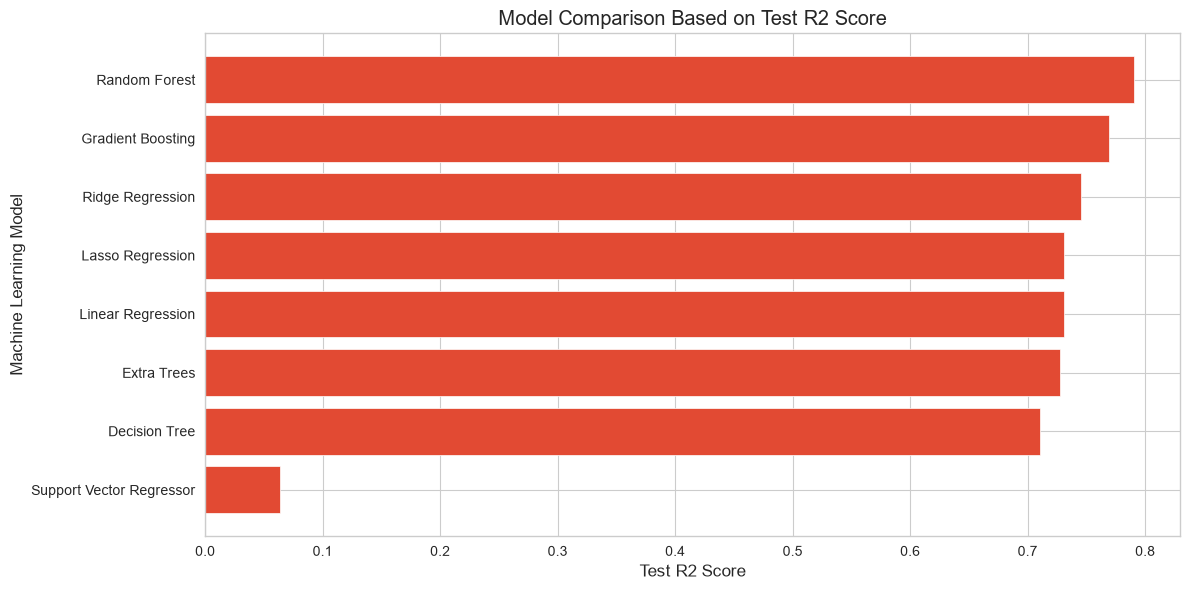

In [143]:
plot_df = results_df.sort_values(
    by="Test R2",
    ascending=True
)

plt.figure(figsize=(12, 6))

plt.barh(
    plot_df["Model"],
    plot_df["Test R2"]
)

plt.title("Model Comparison Based on Test R2 Score")
plt.xlabel("Test R2 Score")
plt.ylabel("Machine Learning Model")

plt.tight_layout()
plt.show()

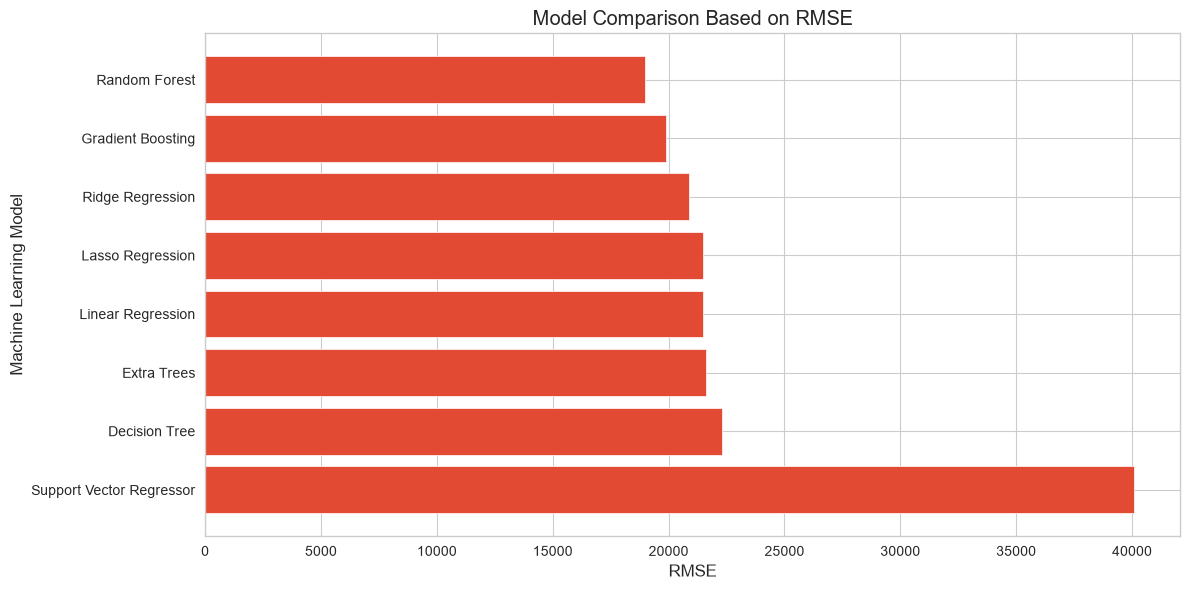

In [144]:
rmse_plot_df = results_df.sort_values(
    by="RMSE",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.barh(
    rmse_plot_df["Model"],
    rmse_plot_df["RMSE"]
)

plt.title("Model Comparison Based on RMSE")
plt.xlabel("RMSE")
plt.ylabel("Machine Learning Model")

plt.tight_layout()
plt.show()

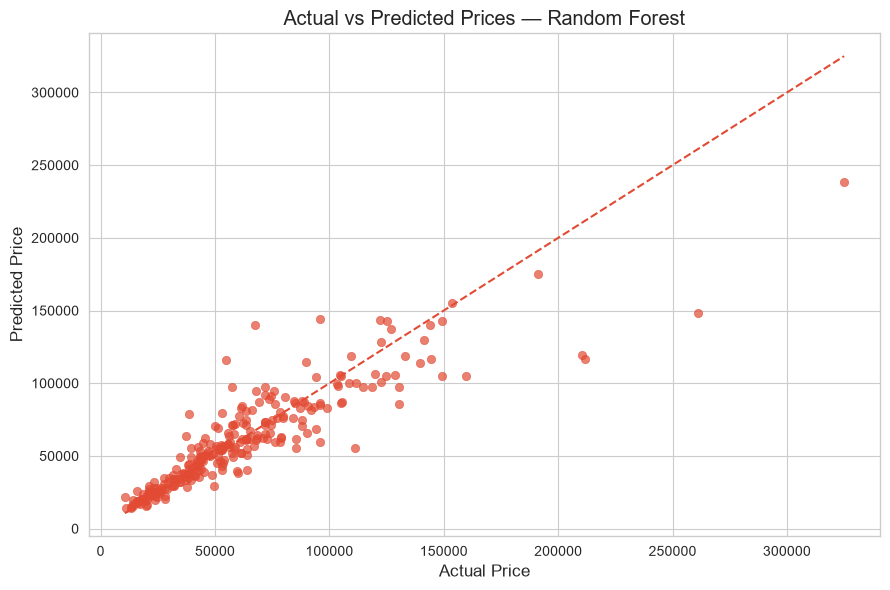

In [145]:
best_predictions = model_predictions[
    best_model_name
]

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_array,
    best_predictions,
    alpha=0.7
)

minimum_value = min(
    y_test_array.min(),
    best_predictions.min()
)

maximum_value = max(
    y_test_array.max(),
    best_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title(
    f"Actual vs Predicted Prices — {best_model_name}"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()

In [146]:
residuals = (
    y_test_array
    - best_predictions
)

print("Residual minimum:", residuals.min())
print("Residual maximum:", residuals.max())
print("Residual average:", residuals.mean())

Residual minimum: -72558.60254399978
Residual maximum: 112419.91199999987
Residual average: 1679.7187094951469


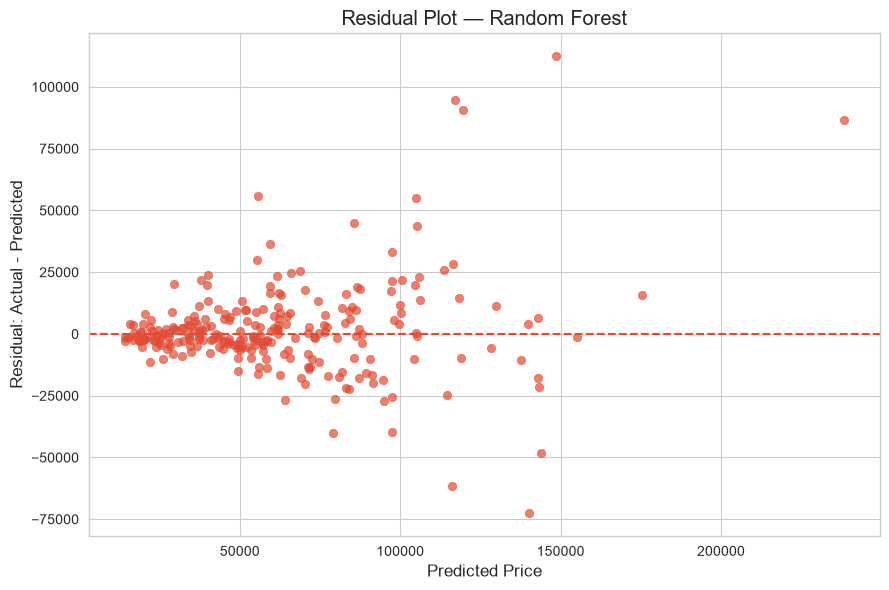

In [147]:
plt.figure(figsize=(9, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    f"Residual Plot — {best_model_name}"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual: Actual - Predicted")

plt.tight_layout()
plt.show()

In [148]:
prediction_comparison = pd.DataFrame({
    "Actual Price": y_test_array,
    "Predicted Price": best_predictions
})

prediction_comparison["Difference"] = (
    prediction_comparison["Actual Price"]
    - prediction_comparison["Predicted Price"]
)

prediction_comparison["Absolute Error"] = (
    prediction_comparison["Difference"].abs()
)

prediction_comparison.head(20).round(2)

,Actual Price,Predicted Price,Difference,Absolute Error
0,24988.32,25872.64,-884.32,884.32
1,41345.28,35959.74,5385.54,5385.54
2,63882.72,40114.98,23767.74,23767.74
3,42357.60,45261.61,-2904.01,2904.01
4,68184.01,62293.04,5890.97,5890.97
5,38308.32,37279.11,1029.21,1029.21
6,111355.20,55610.36,55744.84,55744.84
7,31808.16,34344.98,-2536.82,2536.82
8,51729.55,54464.51,-2734.96,2734.96
9,36336.96,37380.89,-1043.93,1043.93


In [149]:
prediction_comparison.to_csv(
    "../reports/prediction_comparison.csv",
    index=False
)

print("Prediction comparison saved successfully.")

Prediction comparison saved successfully.


In [150]:
print("Saved model files:")

for file_name in os.listdir("../saved_models"):
    print("-", file_name)

print("\nSaved report files:")

for file_name in os.listdir("../reports"):
    print("-", file_name)

Saved model files:
- best_model.pkl
- best_model_info.pkl
- Decision_Tree.pkl
- Extra_Trees.pkl
- Gradient_Boosting.pkl
- Lasso_Regression.pkl
- Linear_Regression.pkl
- Random_Forest.pkl
- Ridge_Regression.pkl
- Support_Vector_Regressor.pkl

Saved report files:
- model_comparison.csv
- prediction_comparison.csv


In [151]:
print("=" * 70)
print("PHASE 6: MODEL TRAINING COMPLETED")
print("=" * 70)

print("Total models trained:", len(results_df))
print("Best model:", best_model_name)
print("Best Test R2:", round(best_test_r2, 4))
print("Best MAE:", round(best_mae, 2))
print("Best RMSE:", round(best_rmse, 2))

print("\nBest model file:")
print("../saved_models/best_model.pkl")

print("\nComparison report:")
print("../reports/model_comparison.csv")

print("=" * 70)

PHASE 6: MODEL TRAINING COMPLETED
Total models trained: 8
Best model: Random Forest
Best Test R2: 0.7901
Best MAE: 11006.72
Best RMSE: 18964.59

Best model file:
../saved_models/best_model.pkl

Comparison report:
../reports/model_comparison.csv


In [152]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd
import joblib

In [153]:
rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [154]:
param_distributions = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

In [155]:
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="r2",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [156]:
random_search.fit(
    X_train_processed,
    y_train_array
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretu

In [158]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation R2:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}

Best Cross Validation R2:
0.8187690160278276


In [ ]:
tuned_random_forest = random_search.best_estimator_

print(tuned_random_forest)

RandomForestRegressor(bootstrap=False, max_features='sqrt', min_samples_split=5,
                      n_estimators=400, n_jobs=-1, random_state=42)


In [160]:
tuned_predictions = tuned_random_forest.predict(
    X_test_processed
)

In [161]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

tuned_r2 = r2_score(
    y_test_array,
    tuned_predictions
)

tuned_mae = mean_absolute_error(
    y_test_array,
    tuned_predictions
)

tuned_mse = mean_squared_error(
    y_test_array,
    tuned_predictions
)

tuned_rmse = np.sqrt(tuned_mse)

print("=" * 60)
print("TUNED RANDOM FOREST RESULTS")
print("=" * 60)

print("R2 Score:", round(tuned_r2, 4))
print("MAE:", round(tuned_mae, 2))
print("MSE:", round(tuned_mse, 2))
print("RMSE:", round(tuned_rmse, 2))

print("=" * 60)

TUNED RANDOM FOREST RESULTS
R2 Score: 0.7721
MAE: 11288.11
MSE: 390559138.5
RMSE: 19762.57


In [162]:
comparison = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Tuned Random Forest"
    ],
    "R2 Score": [
        0.7901,
        tuned_r2
    ],
    "MAE": [
        11006.72,
        tuned_mae
    ],
    "RMSE": [
        18964.59,
        tuned_rmse
    ]
})

comparison

,Model,R2 Score,MAE,RMSE
0,Original Random Forest,0.790100,11006.720000,18964.590000
1,Tuned Random Forest,0.772092,11288.109224,19762.569127


In [163]:
if tuned_r2 > 0.7901:
    print("Tuned Random Forest is better.")
else:
    print("Original Random Forest is still better.")

Original Random Forest is still better.


In [164]:
joblib.dump(
    tuned_random_forest,
    "../saved_models/tuned_random_forest.pkl"
)

print("Tuned Random Forest saved successfully.")

Tuned Random Forest saved successfully.


In [165]:
if tuned_r2 > best_test_r2:
    final_model = tuned_random_forest
    final_model_name = "Tuned Random Forest"
else:
    final_model = best_model
    final_model_name = best_model_name

print("Final selected model:", final_model_name)

Final selected model: Random Forest


In [166]:
joblib.dump(
    final_model,
    "../saved_models/final_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


In [167]:
cv_results = pd.DataFrame(
    random_search.cv_results_
)

cv_results.to_csv(
    "../reports/random_forest_tuning_results.csv",
    index=False
)

print("Tuning results saved successfully.")

Tuning results saved successfully.


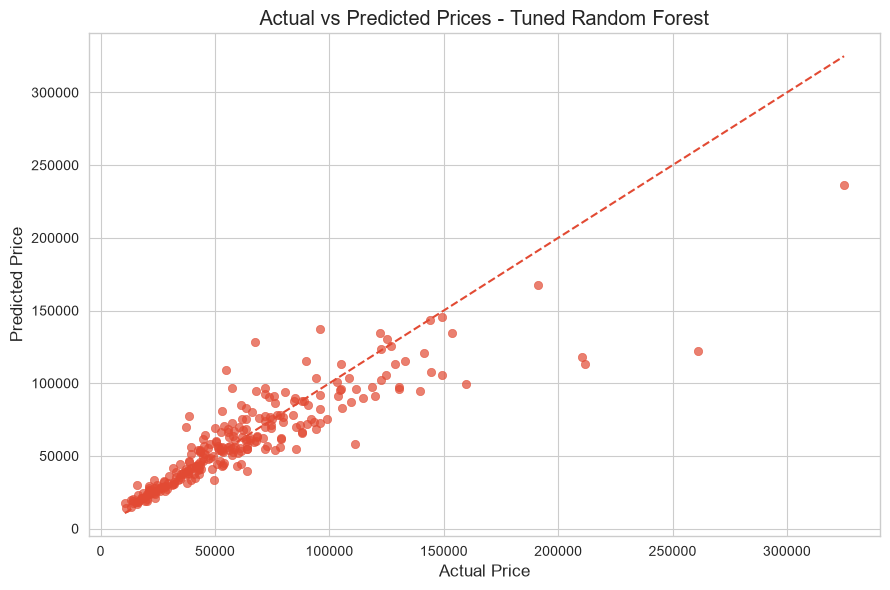

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_array,
    tuned_predictions,
    alpha=0.7
)

minimum_value = min(
    y_test_array.min(),
    tuned_predictions.min()
)

maximum_value = max(
    y_test_array.max(),
    tuned_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Prices - Tuned Random Forest")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()

In [169]:
print("=" * 70)
print("PHASE 7: HYPERPARAMETER TUNING COMPLETED")
print("=" * 70)

print("Original Random Forest R2:", 0.7901)
print("Tuned Random Forest R2:", round(tuned_r2, 4))

print("Original MAE:", 11006.72)
print("Tuned MAE:", round(tuned_mae, 2))

print("Original RMSE:", 18964.59)
print("Tuned RMSE:", round(tuned_rmse, 2))

print("\nFinal selected model:", final_model_name)
print("Final model path: ../saved_models/final_model.pkl")

print("=" * 70)

PHASE 7: HYPERPARAMETER TUNING COMPLETED
Original Random Forest R2: 0.7901
Tuned Random Forest R2: 0.7721
Original MAE: 11006.72
Tuned MAE: 11288.11
Original RMSE: 18964.59
Tuned RMSE: 19762.57

Final selected model: Random Forest
Final model path: ../saved_models/final_model.pkl


In [170]:
import joblib
import pandas as pd
import numpy as np

In [172]:
final_model = joblib.load(
    "../saved_models/final_model.pkl"
)

preprocessor = joblib.load(
    "../saved_scaling/preprocessor.pkl"
)

print("Final model loaded successfully.")
print("Preprocessor loaded successfully.")

Final model loaded successfully.
Preprocessor loaded successfully.


In [173]:
print("Input columns:")
print(X.columns.tolist())

Input columns:
['Company', 'TypeName', 'Inches', 'Ram_GB', 'Weight_kg', 'Touchscreen', 'IPS', 'PPI', 'CPU_Brand', 'SSD_GB', 'HDD_GB', 'Flash_GB', 'Hybrid_GB', 'GPU_Brand', 'OS']


In [174]:
sample_laptop = pd.DataFrame({
    "Company": ["Dell"],
    "TypeName": ["Notebook"],
    "Inches": [15.6],
    "Ram_GB": [8],
    "Weight_kg": [1.8],
    "Touchscreen": [0],
    "IPS": [1],
    "PPI": [141.21],
    "CPU_Brand": ["Intel Core i5"],
    "SSD_GB": [512],
    "HDD_GB": [0],
    "Flash_GB": [0],
    "Hybrid_GB": [0],
    "GPU_Brand": ["Intel"],
    "OS": ["Windows"]
})

sample_laptop

,Company,TypeName,Inches,Ram_GB,Weight_kg,Touchscreen,IPS,PPI,CPU_Brand,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB,GPU_Brand,OS
0,Dell,Notebook,15.6,8,1.8,0,1,141.21,Intel Core i5,512,0,0,0,Intel,Windows


In [175]:
sample_processed = preprocessor.transform(
    sample_laptop
)

print("Processed input shape:")
print(sample_processed.shape)

Processed input shape:
(1, 49)


In [176]:
from scipy import sparse

if sparse.issparse(sample_processed):
    sample_processed = sample_processed.toarray()

print("Processed type:", type(sample_processed))

Processed type: <class 'numpy.ndarray'>


In [177]:
predicted_price = final_model.predict(
    sample_processed
)[0]

print("Predicted Laptop Price:")
print(round(predicted_price, 2))

Predicted Laptop Price:
78271.03


In [178]:
print(
    f"Estimated Laptop Price: ₹{predicted_price:,.2f}"
)

Estimated Laptop Price: ₹78,271.03


In [179]:
def predict_laptop_price(
    company,
    type_name,
    inches,
    ram_gb,
    weight_kg,
    touchscreen,
    ips,
    ppi,
    cpu_brand,
    ssd_gb,
    hdd_gb,
    flash_gb,
    hybrid_gb,
    gpu_brand,
    os_name
):
    input_data = pd.DataFrame({
        "Company": [company],
        "TypeName": [type_name],
        "Inches": [inches],
        "Ram_GB": [ram_gb],
        "Weight_kg": [weight_kg],
        "Touchscreen": [touchscreen],
        "IPS": [ips],
        "PPI": [ppi],
        "CPU_Brand": [cpu_brand],
        "SSD_GB": [ssd_gb],
        "HDD_GB": [hdd_gb],
        "Flash_GB": [flash_gb],
        "Hybrid_GB": [hybrid_gb],
        "GPU_Brand": [gpu_brand],
        "OS": [os_name]
    })

    processed_data = preprocessor.transform(
        input_data
    )

    if sparse.issparse(processed_data):
        processed_data = processed_data.toarray()

    prediction = final_model.predict(
        processed_data
    )[0]

    return round(prediction, 2)

In [180]:
price = predict_laptop_price(
    company="HP",
    type_name="Notebook",
    inches=15.6,
    ram_gb=16,
    weight_kg=1.9,
    touchscreen=0,
    ips=1,
    ppi=141.21,
    cpu_brand="Intel Core i7",
    ssd_gb=512,
    hdd_gb=0,
    flash_gb=0,
    hybrid_gb=0,
    gpu_brand="Nvidia",
    os_name="Windows"
)

print(f"Predicted Laptop Price: ₹{price:,.2f}")

Predicted Laptop Price: ₹86,050.96


In [181]:
from sklearn.pipeline import Pipeline

In [182]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_model)
])

In [183]:
joblib.dump(
    final_pipeline,
    "../saved_models/laptop_price_pipeline.pkl"
)

print("Complete prediction pipeline saved successfully.")

Complete prediction pipeline saved successfully.


In [184]:
loaded_pipeline = joblib.load(
    "../saved_models/laptop_price_pipeline.pkl"
)

pipeline_prediction = loaded_pipeline.predict(
    sample_laptop
)[0]

print(
    f"Pipeline Predicted Price: ₹{pipeline_prediction:,.2f}"
)

Pipeline Predicted Price: ₹78,271.03


In [185]:
input_options = {
    "Company": sorted(
        laptop_df["Company"].dropna().unique().tolist()
    ),

    "TypeName": sorted(
        laptop_df["TypeName"].dropna().unique().tolist()
    ),

    "CPU_Brand": sorted(
        laptop_df["CPU_Brand"].dropna().unique().tolist()
    ),

    "GPU_Brand": sorted(
        laptop_df["GPU_Brand"].dropna().unique().tolist()
    ),

    "OS": sorted(
        laptop_df["OS"].dropna().unique().tolist()
    ),

    "Ram_GB": sorted(
        laptop_df["Ram_GB"].dropna().unique().tolist()
    ),

    "SSD_GB": sorted(
        laptop_df["SSD_GB"].dropna().unique().tolist()
    ),

    "HDD_GB": sorted(
        laptop_df["HDD_GB"].dropna().unique().tolist()
    )
}

In [186]:
joblib.dump(
    input_options,
    "../saved_models/input_options.pkl"
)

print("Input options saved successfully.")

Input options saved successfully.


In [187]:
print("=" * 70)
print("PHASE 8: FINAL PREDICTION PIPELINE COMPLETED")
print("=" * 70)

print("Final Model: Random Forest")
print("Final R2 Score: 0.7901")

print("\nSaved Files:")
print("../saved_models/final_model.pkl")
print("../saved_scaling/preprocessor.pkl")
print("../saved_models/laptop_price_pipeline.pkl")
print("../saved_models/input_options.pkl")

print("\nSample Prediction:")
print(f"₹{pipeline_prediction:,.2f}")

print("=" * 70)

PHASE 8: FINAL PREDICTION PIPELINE COMPLETED
Final Model: Random Forest
Final R2 Score: 0.7901

Saved Files:
../saved_models/final_model.pkl
../saved_scaling/preprocessor.pkl
../saved_models/laptop_price_pipeline.pkl
../saved_models/input_options.pkl

Sample Prediction:
₹78,271.03
